In [ ]:
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
%matplotlib inline

In [ ]:
# For splitting data into training and testing sets
from sklearn.model_selection import train_test_split

In [ ]:
# For cross-validation during stacking ensemble
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [ ]:
# For standardising numerical features (scaling)
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# The four individual machine learning models
from sklearn.svm import SVC  # Support Vector Machine
from sklearn.linear_model import LogisticRegression  # Logistic Regression
from sklearn.ensemble import RandomForestClassifier  # Random Forest

In [ ]:
# For the stacking ensemble
from sklearn.ensemble import StackingClassifier

In [ ]:
# These are used to measure how well our models perform
from sklearn.metrics import (
    accuracy_score,        # Overall accuracy
    precision_score,       # Precision metric
    recall_score,          # Recall metric
    f1_score,              # F1 score
    classification_report, # Full detailed report
    confusion_matrix       # Confusion matrix
)

In [ ]:
# For hyperparameter tuning (finding best model settings)
from sklearn.model_selection import GridSearchCV

In [ ]:
try:
    from catboost import CatBoostClassifier
    print("CatBoost imported successfully")
except ImportError:
    print("Installing CatBoost...")
    import subprocess
    subprocess.run(["pip", "install", "catboost", "-q"])
    from catboost import CatBoostClassifier
    print("CatBoost installed and imported successfully")

Installing CatBoost...
CatBoost installed and imported successfully


In [ ]:
# PyMC for Bayesian Beta Regression
try:
    import pymc as pm
    import arviz as az  # Used for visualising Bayesian results
    print("PyMC imported successfully")
except ImportError:
    print("Installing PyMC...")
    import subprocess
    subprocess.run(["pip", "install", "pymc", "-q"])
    subprocess.run(["pip", "install", "arviz", "-q"])
    import pymc as pm
    import arviz as az
    print("PyMC installed and imported successfully")


PyMC imported successfully


In [ ]:
#Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

print("\n All libraries imported successfully!")
print("Environment is ready to begin the research.")


 All libraries imported successfully!
Environment is ready to begin the research.


In [ ]:

from google.colab import files

print("Please upload your dataset file...")
uploaded = files.upload()

Please upload your dataset file...


Saving project_kpi_dataset_v3.csv to project_kpi_dataset_v3.csv


In [ ]:
df = pd.read_csv('project_kpi_dataset_v3.csv')

print(f"\n Dataset loaded successfully!")
print(f" Total rows: {df.shape[0]}")
print(f" Total columns: {df.shape[1]}")
print(f"\n Column names:")
print(df.columns.tolist())


 Dataset loaded successfully!
 Total rows: 1000
 Total columns: 24

 Column names:
['ProjectID', 'Domain', 'PlannedStartDate', 'PlannedDurationDays', 'PlannedCost', 'TeamSize', 'Complexity', 'RiskLevel', 'NumChangeRequests', 'SprintVelocity', 'EarlyMilestonesPct', 'TechnicalDebtScore', 'ResourceUtilizationPct', 'ActualDurationDays', 'DelayDays', 'ActualCost', 'CostOverrunPct', 'CustomerSatisfaction', 'ProjectSuccess', 'PlannedEndDate', 'ActualEndDate', 'OnTime', 'MajorDelayFlag', 'CostOverrunBucket']


In [ ]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,ProjectID,Domain,PlannedStartDate,PlannedDurationDays,PlannedCost,TeamSize,Complexity,RiskLevel,NumChangeRequests,SprintVelocity,...,DelayDays,ActualCost,CostOverrunPct,CustomerSatisfaction,ProjectSuccess,PlannedEndDate,ActualEndDate,OnTime,MajorDelayFlag,CostOverrunBucket
0,PJT1954,Mobile App,2019-05-13,63,34421,6,4,Medium,7,42.6,...,19,45873,0.3327,7.65,0,2019-07-15,2019-08-03,0,1,25-50%
1,PJT8032,Data Engineering,2020-09-28,172,36598,7,3,High,3,46.0,...,-1,37162,0.0154,6.18,0,2021-03-19,2021-03-18,1,0,<10%
2,PJT2930,Infrastructure,2019-11-29,338,75224,7,3,Medium,6,39.7,...,23,73539,-0.0224,7.42,0,2020-11-01,2020-11-24,0,0,Under/OnBudget
3,PJT7989,AI/ML,2018-04-29,260,153405,3,5,Medium,6,81.9,...,84,230138,0.5002,7.07,0,2019-01-14,2019-04-08,0,1,>50%
4,PJT9475,Web App,2018-07-26,300,295464,6,2,High,4,40.3,...,46,354852,0.2010,6.95,0,2019-05-22,2019-07-07,0,0,10-25%


In [ ]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProjectID               1000 non-null   object 
 1   Domain                  1000 non-null   object 
 2   PlannedStartDate        1000 non-null   object 
 3   PlannedDurationDays     1000 non-null   int64  
 4   PlannedCost             1000 non-null   int64  
 5   TeamSize                1000 non-null   int64  
 6   Complexity              1000 non-null   int64  
 7   RiskLevel               1000 non-null   object 
 8   NumChangeRequests       1000 non-null   int64  
 9   SprintVelocity          1000 non-null   float64
 10  EarlyMilestonesPct      1000 non-null   float64
 11  TechnicalDebtScore      1000 non-null   float64
 12  ResourceUtilizationPct  1000 non-null   float64
 13  ActualDurationDays      1000 non-null   int64  
 14  DelayDays           

In [ ]:
print("Statistical summary:")
df.describe()

Statistical summary:


,PlannedDurationDays,PlannedCost,TeamSize,Complexity,NumChangeRequests,SprintVelocity,EarlyMilestonesPct,TechnicalDebtScore,ResourceUtilizationPct,ActualDurationDays,DelayDays,ActualCost,CostOverrunPct,CustomerSatisfaction,ProjectSuccess,OnTime,MajorDelayFlag
count,1000.00000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,182.34100,1.922775e+05,5.801000,2.989000,4.931000,44.58860,0.623049,5.505130,0.708428,201.737000,19.396000,2.231492e+05,0.166652,7.707960,0.330000,0.24900,0.184000
std,114.58349,2.778457e+05,2.516293,1.104581,2.150084,14.62017,0.160968,1.808585,0.148008,130.805389,35.557355,3.265850e+05,0.230881,1.021492,0.470448,0.43265,0.387678
min,30.00000,5.000000e+03,2.000000,1.000000,0.000000,15.00000,0.102000,1.430000,0.240000,25.000000,-77.000000,3.709000e+03,-0.300000,5.230000,0.000000,0.00000,0.000000
25%,75.75000,4.543925e+04,4.000000,2.000000,3.000000,34.30000,0.513000,4.147500,0.613000,84.000000,1.000000,5.203975e+04,0.002950,6.930000,0.000000,0.00000,0.000000
50%,163.00000,9.881850e+04,5.000000,3.000000,5.000000,44.50000,0.631500,5.530000,0.729000,179.000000,11.000000,1.132440e+05,0.160300,7.500000,0.000000,0.00000,0.000000
75%,274.25000,2.212780e+05,7.000000,4.000000,6.000000,54.40000,0.743250,6.882500,0.819500,300.000000,33.000000,2.536935e+05,0.316075,8.552500,1.000000,0.00000,0.000000
max,420.00000,2.000000e+06,15.000000,5.000000,14.000000,88.80000,0.965000,9.770000,0.986000,647.000000,229.000000,2.876000e+06,0.903100,10.000000,1.000000,1.00000,1.000000


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values in each column:
ProjectID                 0
Domain                    0
PlannedStartDate          0
PlannedDurationDays       0
PlannedCost               0
TeamSize                  0
Complexity                0
RiskLevel                 0
NumChangeRequests         0
SprintVelocity            0
EarlyMilestonesPct        0
TechnicalDebtScore        0
ResourceUtilizationPct    0
ActualDurationDays        0
DelayDays                 0
ActualCost                0
CostOverrunPct            0
CustomerSatisfaction      0
ProjectSuccess            0
PlannedEndDate            0
ActualEndDate             0
OnTime                    0
MajorDelayFlag            0
CostOverrunBucket         0
dtype: int64

Total missing values: 0


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Reset matplotlib to default clean style
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Matplotlib version: 3.10.0
Seaborn version: 0.13.2


In [ ]:
# TARGET VARIABLE 1:ProjectSuccess Distribution
print("=" * 60)
print("TARGET VARIABLE 1: ProjectSuccess Distribution")
print("=" * 60)

success_counts = df['ProjectSuccess'].value_counts().sort_index()
print(success_counts)
print(f"\nSuccess Rate: {df['ProjectSuccess'].mean()*100:.1f}%")
print(f"Failure Rate: {(1 - df['ProjectSuccess'].mean())*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

TARGET VARIABLE 1: ProjectSuccess Distribution
ProjectSuccess
0    670
1    330
Name: count, dtype: int64

Success Rate: 33.0%
Failure Rate: 67.0%


In [ ]:
axes[0].bar(
    ['Failed (0)', 'Succeeded (1)'],
    success_counts.values,
    color=['#F5C4B3', '#9FE1CB'],
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_title('Project Success Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Project Outcome')
axes[0].set_ylabel('Number of Projects')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(success_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

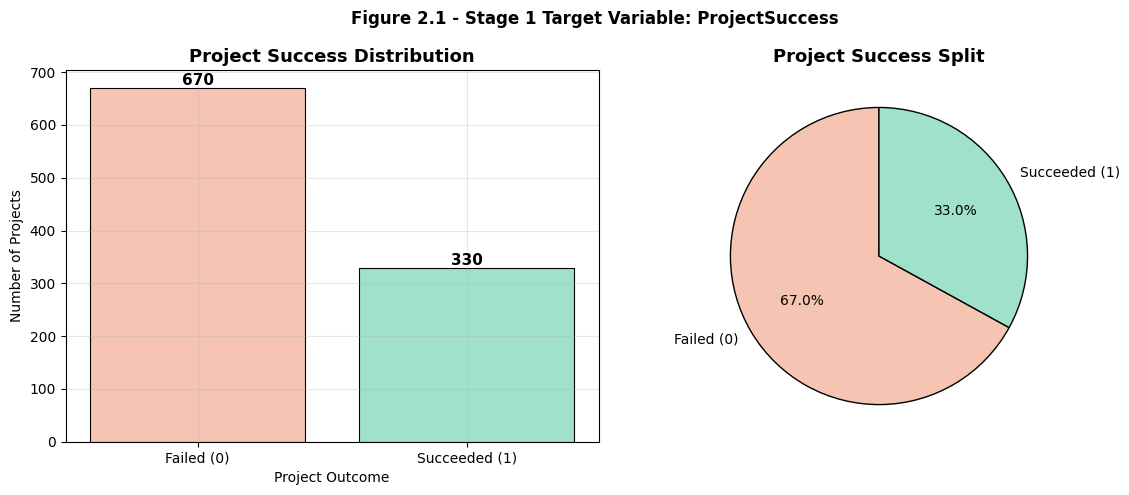

Figure 2.1 saved successfully


In [ ]:
axes[1].pie(
    success_counts.values,
    labels=['Failed (0)', 'Succeeded (1)'],
    colors=['#F5C4B3', '#9FE1CB'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[1].set_title('Project Success Split', fontsize=13, fontweight='bold')

plt.suptitle('Figure 2.1 - Stage 1 Target Variable: ProjectSuccess',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_1_project_success.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 2.1 saved successfully")

TARGET VARIABLE 2: CostOverrunBucket Distribution
CostOverrunBucket
25-50%            273
10-25%            269
Under/OnBudget    245
<10%              136
>50%               77
Name: count, dtype: int64


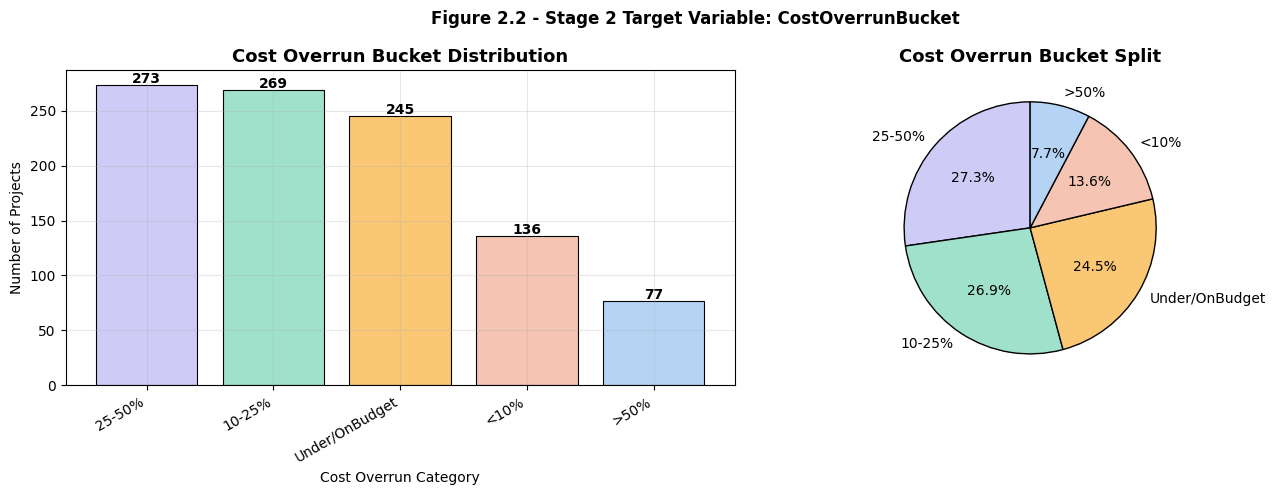

Figure 2.2 saved successfully


In [ ]:

# TARGET VARIABLE 2: CostOverrunBucket

print("=" * 60)
print("TARGET VARIABLE 2: CostOverrunBucket Distribution")
print("=" * 60)

bucket_counts = df['CostOverrunBucket'].value_counts()
print(bucket_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bucket = ['#CECBF6', '#9FE1CB', '#FAC775', '#F5C4B3', '#B5D4F4']

# Bar chart
axes[0].bar(
    range(len(bucket_counts)),
    bucket_counts.values,
    color=colors_bucket[:len(bucket_counts)],
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_xticks(range(len(bucket_counts)))
axes[0].set_xticklabels(bucket_counts.index, rotation=30, ha='right')
axes[0].set_title('Cost Overrun Bucket Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost Overrun Category')
axes[0].set_ylabel('Number of Projects')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(
    bucket_counts.values,
    labels=bucket_counts.index,
    colors=colors_bucket[:len(bucket_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[1].set_title('Cost Overrun Bucket Split', fontsize=13, fontweight='bold')

plt.suptitle('Figure 2.2 - Stage 2 Target Variable: CostOverrunBucket',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_2_cost_overrun_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 2.2 saved successfully")

TARGET VARIABLE 3: CostOverrunPct Distribution
count    1000.000000
mean        0.166652
std         0.230881
min        -0.300000
25%         0.002950
50%         0.160300
75%         0.316075
max         0.903100
Name: CostOverrunPct, dtype: float64


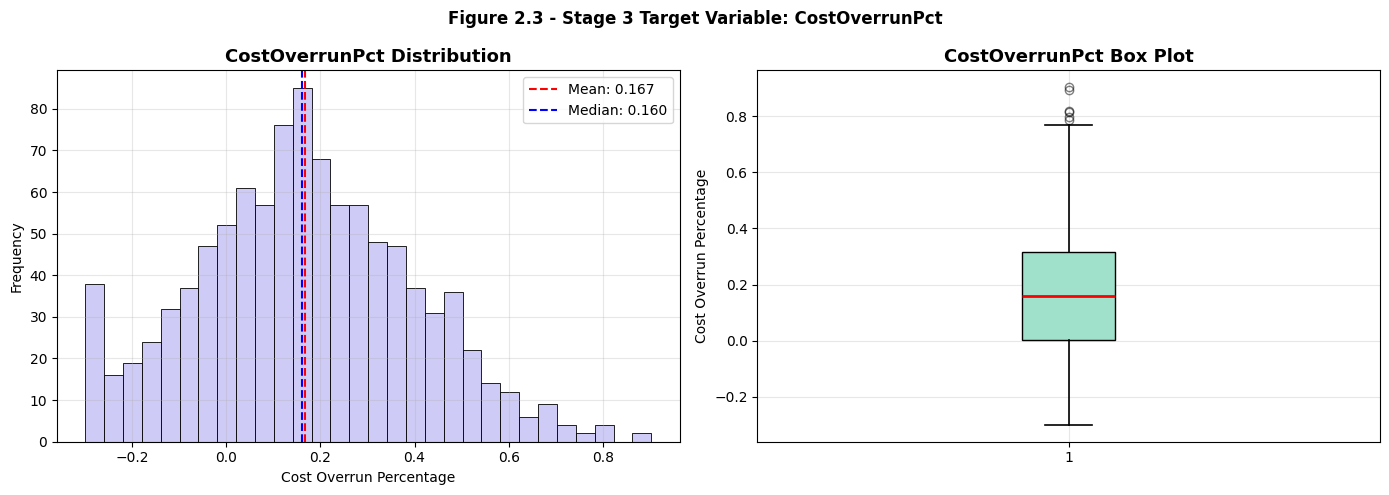

Figure 2.3 saved successfully


In [ ]:

# TARGET VARIABLE 3: CostOverrunPct


print("=" * 60)
print("TARGET VARIABLE 3: CostOverrunPct Distribution")
print("=" * 60)
print(df['CostOverrunPct'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    df['CostOverrunPct'],
    bins=30,
    color='#CECBF6',
    edgecolor='black',
    linewidth=0.6
)
axes[0].axvline(
    df['CostOverrunPct'].mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Mean: {df['CostOverrunPct'].mean():.3f}"
)
axes[0].axvline(
    df['CostOverrunPct'].median(),
    color='blue', linestyle='--', linewidth=1.5,
    label=f"Median: {df['CostOverrunPct'].median():.3f}"
)
axes[0].set_title('CostOverrunPct Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost Overrun Percentage')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
bp = axes[1].boxplot(
    df['CostOverrunPct'],
    patch_artist=True,
    boxprops=dict(facecolor='#9FE1CB', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', color='orange', alpha=0.5)
)
axes[1].set_title('CostOverrunPct Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cost Overrun Percentage')
axes[1].grid(alpha=0.3)

plt.suptitle('Figure 2.3 - Stage 3 Target Variable: CostOverrunPct',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_3_cost_overrun_pct.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 2.3 saved successfully")

NUMERICAL FEATURE DISTRIBUTIONS


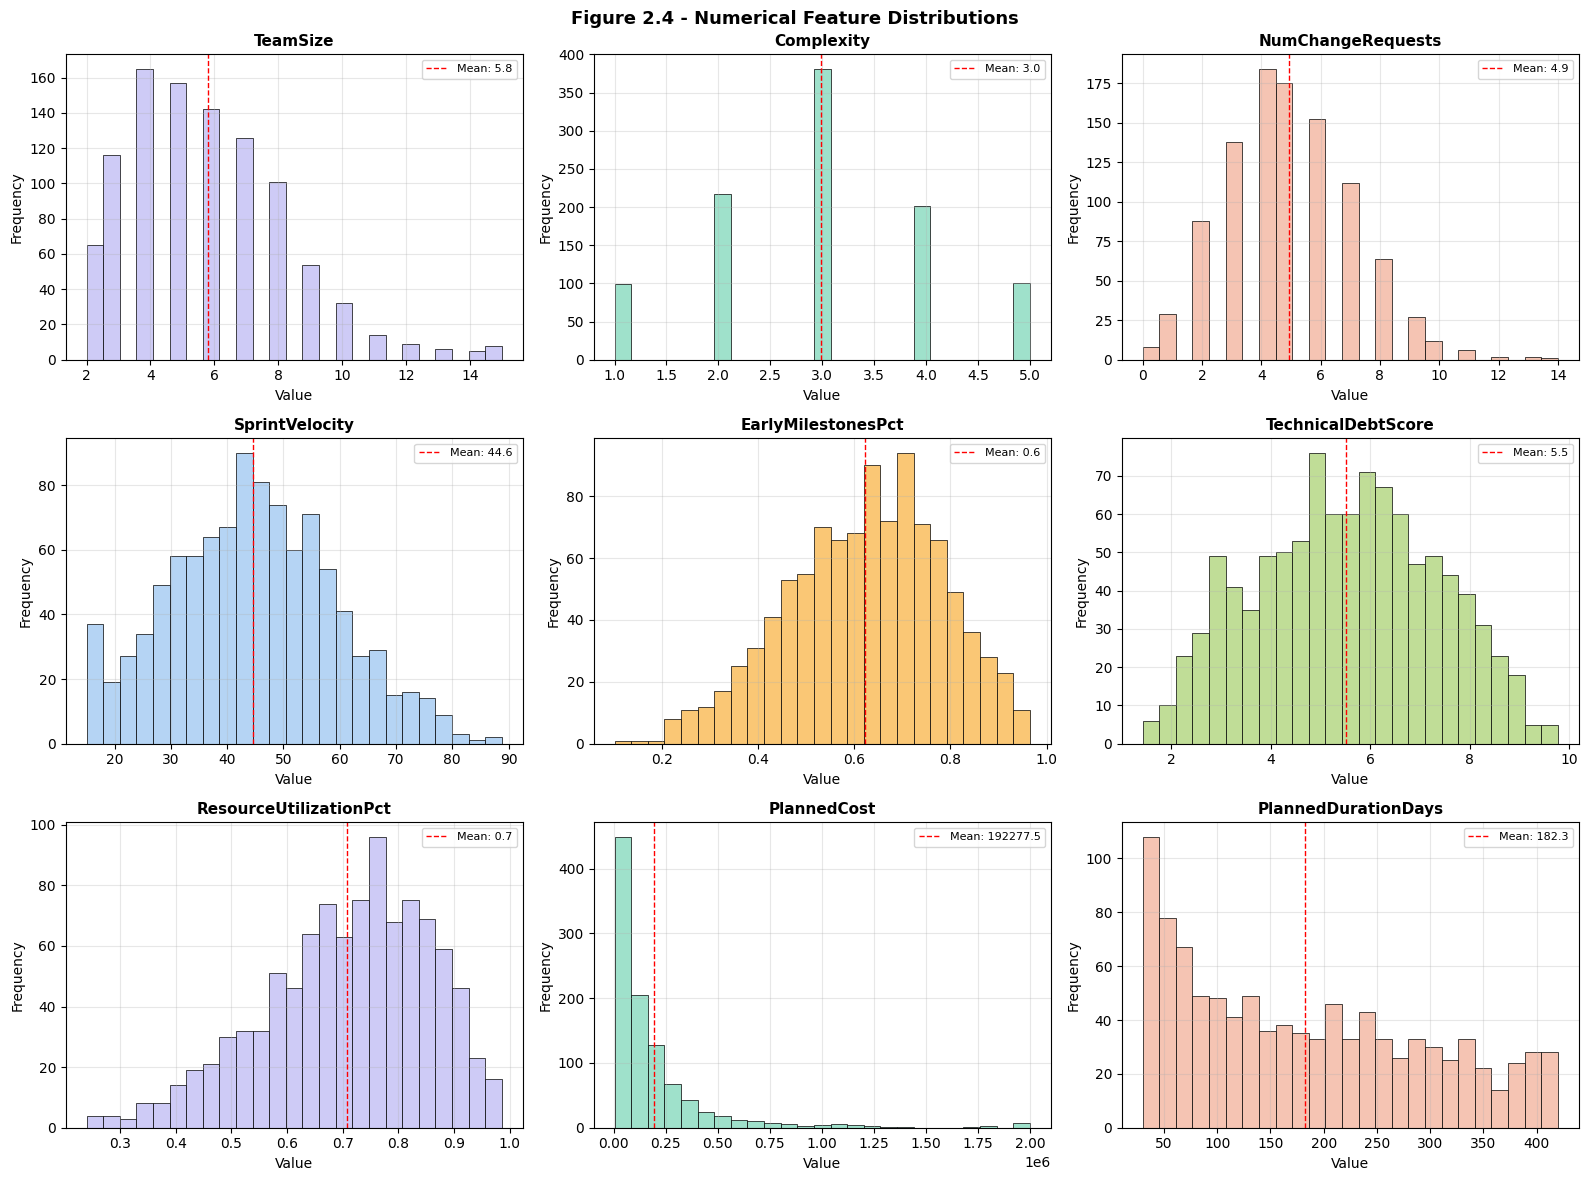

Figure 2.4 saved successfully


In [ ]:

# FEATURE DISTRIBUTIONS - All Numerical Input Features

print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

numerical_features = [
    'TeamSize',
    'Complexity',
    'NumChangeRequests',
    'SprintVelocity',
    'EarlyMilestonesPct',
    'TechnicalDebtScore',
    'ResourceUtilizationPct',
    'PlannedCost',
    'PlannedDurationDays'
]

colors_list = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4',
               '#FAC775', '#C0DD97', '#CECBF6', '#9FE1CB', '#F5C4B3']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(
        df[col], bins=25,
        color=colors_list[i],
        edgecolor='black',
        linewidth=0.5
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(
        df[col].mean(), color='red',
        linestyle='--', linewidth=1,
        label=f'Mean: {df[col].mean():.1f}'
    )
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Figure 2.4 - Numerical Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 2.4 saved successfully")

CATEGORICAL FEATURE ANALYSIS
RiskLevel distribution:
RiskLevel
Medium    436
Low       313
High      251
Name: count, dtype: int64

Domain distribution:
Domain
Web App             298
Mobile App          205
AI/ML               168
Internal Tool       124
Infrastructure      118
Data Engineering     87
Name: count, dtype: int64


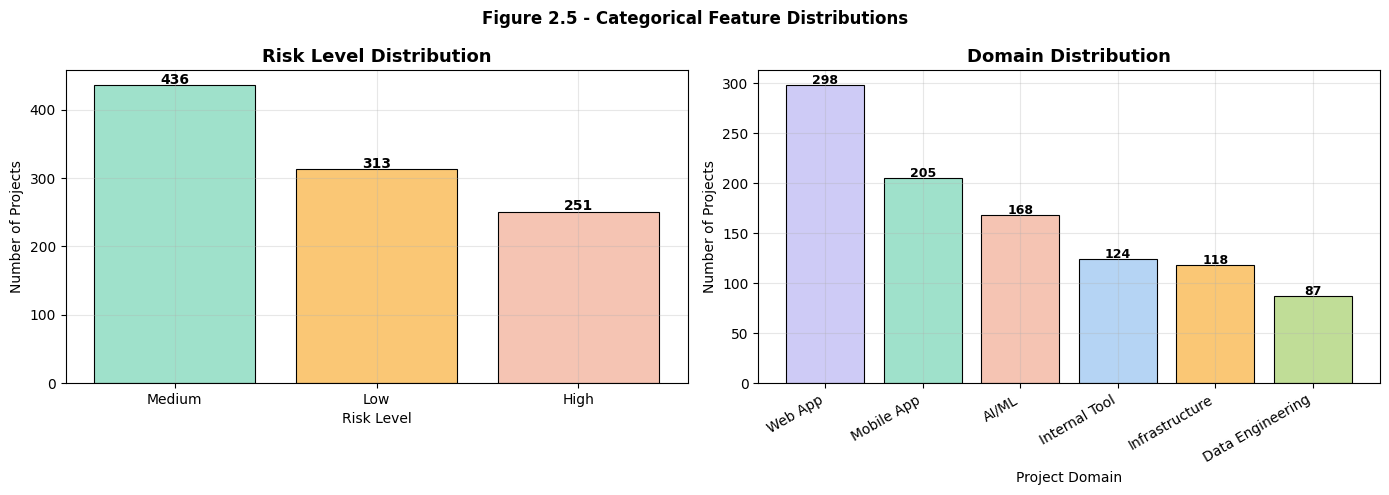

Figure 2.5 saved successfully


In [ ]:

# CATEGORICAL FEATURE DISTRIBUTIONS


print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RiskLevel
risk_counts = df['RiskLevel'].value_counts()
print("RiskLevel distribution:")
print(risk_counts)

axes[0].bar(
    range(len(risk_counts)),
    risk_counts.values,
    color=['#9FE1CB', '#FAC775', '#F5C4B3'],
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels(risk_counts.index, rotation=0)
axes[0].set_title('Risk Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Projects')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Domain
domain_counts = df['Domain'].value_counts()
print("\nDomain distribution:")
print(domain_counts)

domain_colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4', '#FAC775', '#C0DD97']
axes[1].bar(
    range(len(domain_counts)),
    domain_counts.values,
    color=domain_colors[:len(domain_counts)],
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_xticks(range(len(domain_counts)))
axes[1].set_xticklabels(domain_counts.index, rotation=30, ha='right')
axes[1].set_title('Domain Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Project Domain')
axes[1].set_ylabel('Number of Projects')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(domain_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Figure 2.5 - Categorical Feature Distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_5_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 2.5 saved successfully")

CORRELATION HEATMAP


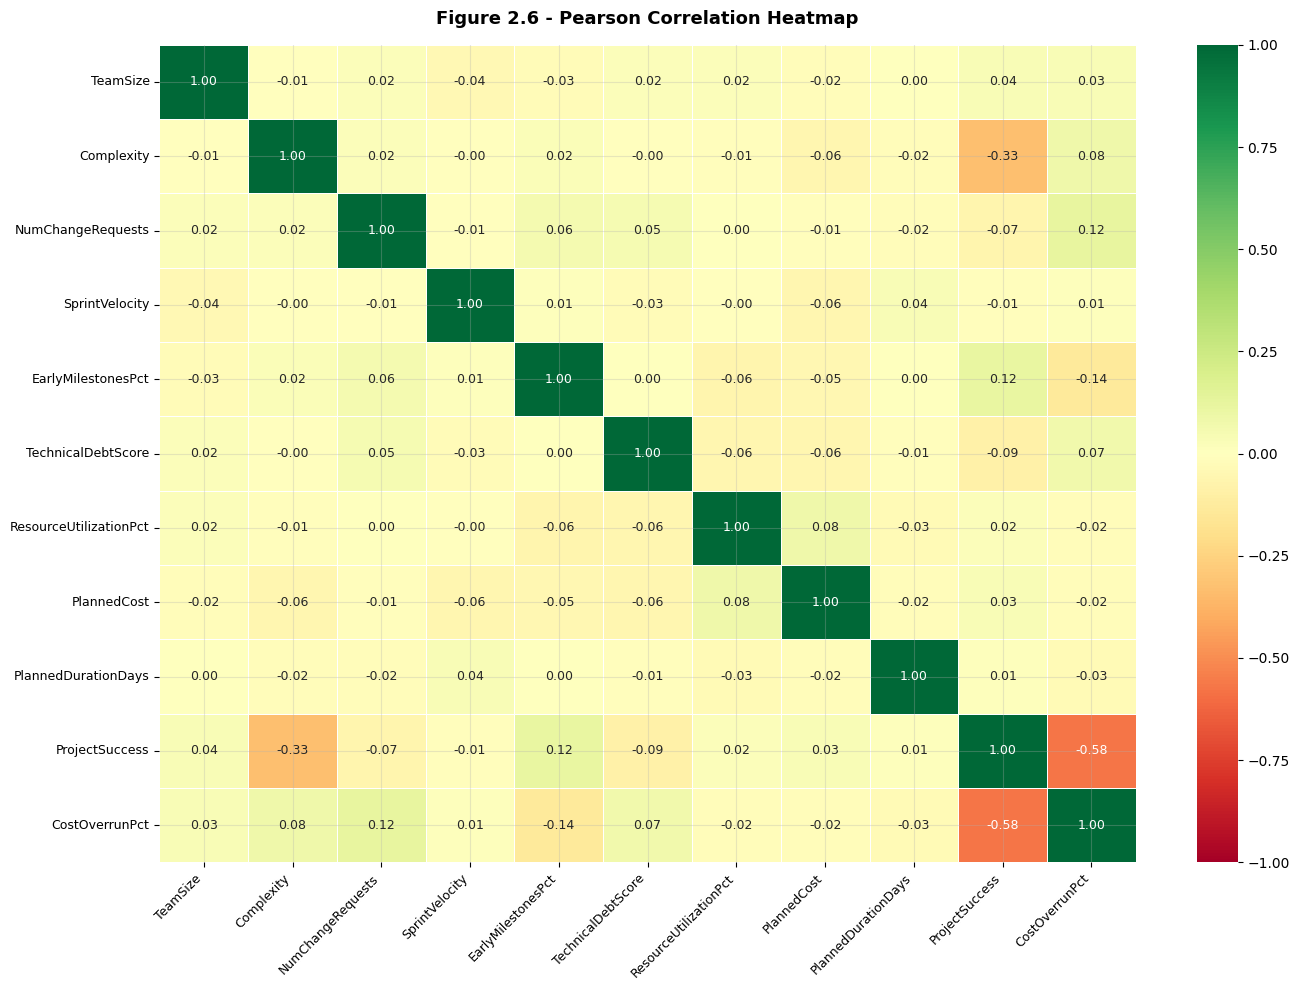


Top correlations with ProjectSuccess:
CostOverrunPct           -0.577951
Complexity               -0.330111
EarlyMilestonesPct        0.116506
TechnicalDebtScore       -0.090804
NumChangeRequests        -0.066532
TeamSize                  0.038618
PlannedCost               0.032596
ResourceUtilizationPct    0.020583
SprintVelocity           -0.014006
PlannedDurationDays       0.009479
Name: ProjectSuccess, dtype: float64
Figure 2.6 saved successfully


In [ ]:

# CORRELATION HEATMAP


print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

corr_columns = [
    'TeamSize', 'Complexity', 'NumChangeRequests',
    'SprintVelocity', 'EarlyMilestonesPct', 'TechnicalDebtScore',
    'ResourceUtilizationPct', 'PlannedCost', 'PlannedDurationDays',
    'ProjectSuccess', 'CostOverrunPct'
]

corr_columns = [col for col in corr_columns if col in df.columns]
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    vmin=-1, vmax=1
)
plt.title('Figure 2.6 - Pearson Correlation Heatmap',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig2_6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("\nTop correlations with ProjectSuccess:")
correlations = corr_matrix['ProjectSuccess'].drop('ProjectSuccess').sort_values(
    key=abs, ascending=False)
print(correlations)
print("Figure 2.6 saved successfully")

FEATURE BEHAVIOUR: SUCCESSFUL vs FAILED PROJECTS


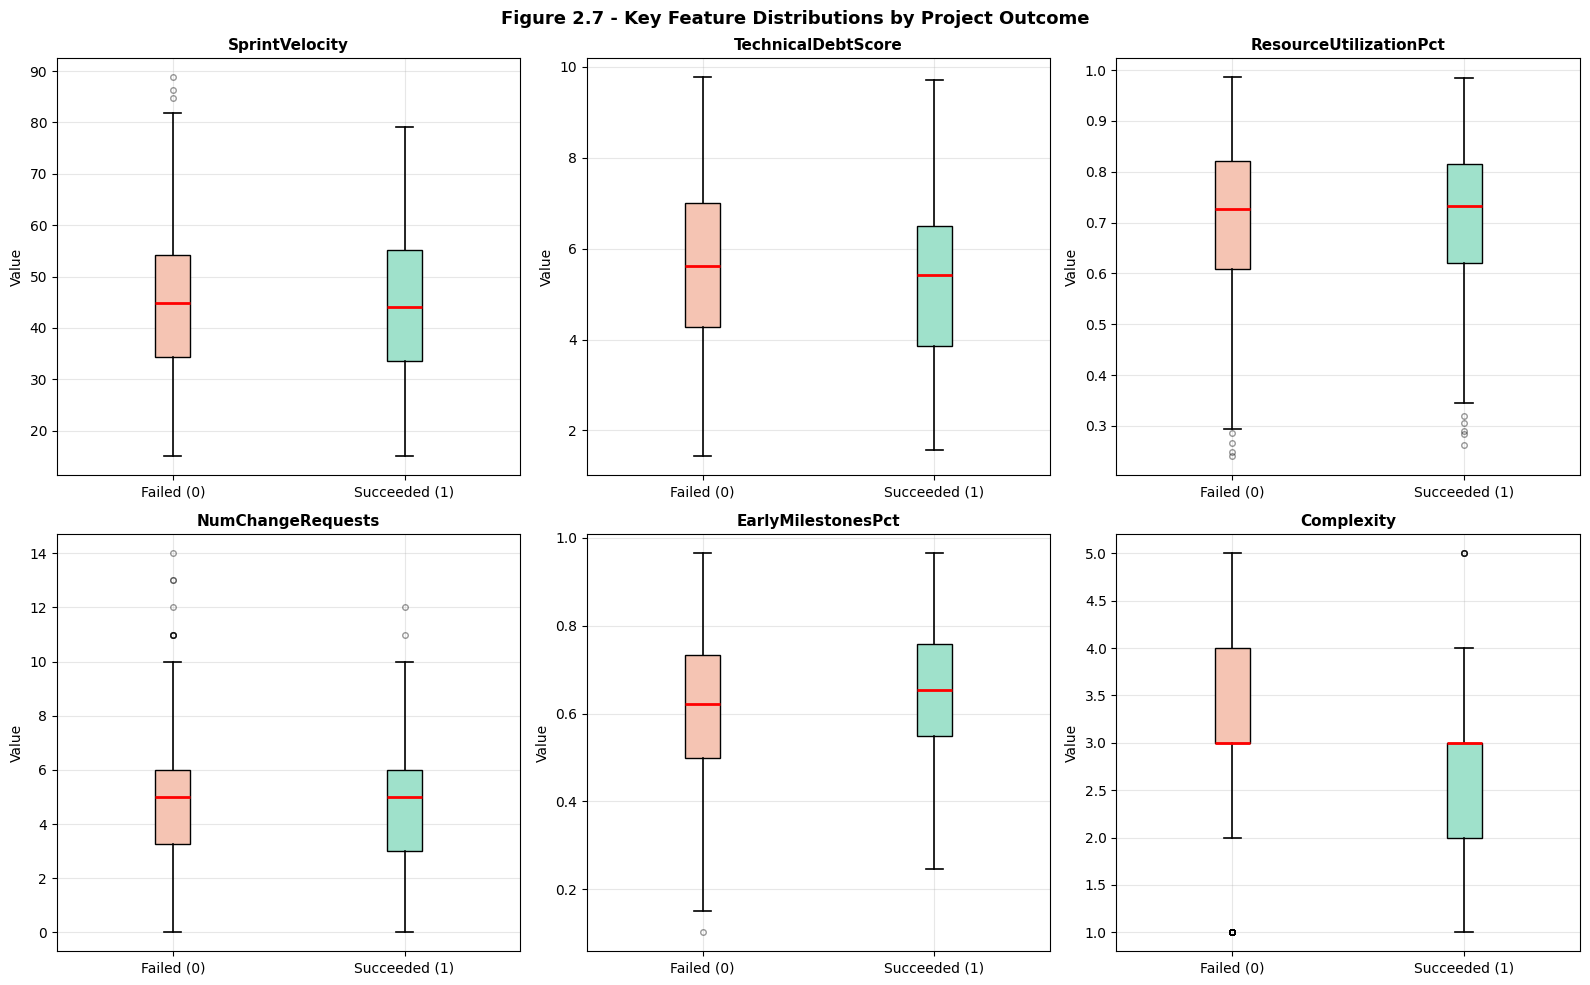

In [ ]:

# FEATURE VS TARGET: SUCCESS vs FAILED


print("=" * 60)
print("FEATURE BEHAVIOUR: SUCCESSFUL vs FAILED PROJECTS")
print("=" * 60)

key_features = [
    'SprintVelocity', 'TechnicalDebtScore',
    'ResourceUtilizationPct', 'NumChangeRequests',
    'EarlyMilestonesPct', 'Complexity'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    failed = df[df['ProjectSuccess'] == 0][feature].values
    succeeded = df[df['ProjectSuccess'] == 1][feature].values

    bp = axes[i].boxplot(
        [failed, succeeded],
        labels=['Failed (0)', 'Succeeded (1)'],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        flierprops=dict(marker='o', alpha=0.4, markersize=4)
    )
    bp['boxes'][0].set_facecolor('#F5C4B3')
    bp['boxes'][1].set_facecolor('#9FE1CB')

    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Figure 2.7 - Key Feature Distributions by Project Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_7_feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



In [ ]:
print("=" * 60)
print("SECTION 5: DATA PREPROCESSING")
print("=" * 60)

# First let us make a copy of the original dataframe
# We always work on a copy so the original data is preserved
# If anything goes wrong we can go back to df
df_processed = df.copy()

print(f"Working copy created. Shape: {df_processed.shape}")

SECTION 5: DATA PREPROCESSING
Working copy created. Shape: (1000, 24)


In [ ]:
# STEP 5.1: REMOVE LEAKAGE COLUMNS

# Data leakage means including information in the model that would NOT be available at the time of prediction in a real scenario.
leakage_columns = [
    'ProjectID',          # Just an ID, not a predictor
    'ActualCost',         # Only known after project ends
    'ActualDurationDays', # Only known after project ends
    'DelayDays',          # Only known after project ends
    'OnTime',             # Derived from actual end date
    'MajorDelayFlag',     # Derived from delay outcome
    'PlannedStartDate',   # Date string, not useful as raw feature
    'PlannedEndDate',     # Date string, not useful as raw feature
    'ActualEndDate'       # Date string, not useful as raw feature
]

# Remove these columns from our working copy
df_processed = df_processed.drop(columns=leakage_columns)

print("STEP 5.1: Leakage columns removed")
print(f"Columns remaining: {df_processed.shape[1]}")
print(f"Remaining columns: {df_processed.columns.tolist()}")

STEP 5.1: Leakage columns removed
Columns remaining: 15
Remaining columns: ['Domain', 'PlannedDurationDays', 'PlannedCost', 'TeamSize', 'Complexity', 'RiskLevel', 'NumChangeRequests', 'SprintVelocity', 'EarlyMilestonesPct', 'TechnicalDebtScore', 'ResourceUtilizationPct', 'CostOverrunPct', 'CustomerSatisfaction', 'ProjectSuccess', 'CostOverrunBucket']


In [ ]:
# STEP 5.2: ENCODE CATEGORICAL VARIABLES

# Machine learning models cannot work with text values .We need to convert them to numbers
print("STEP 5.2: Encoding categorical variables")
print()

# Encode RiskLevel (Ordinal Encoding)
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['RiskLevel'] = df_processed['RiskLevel'].map(risk_mapping)

print("RiskLevel encoded:")
print("  Low -> 0, Medium -> 1, High -> 2")
print(f"  Unique values after encoding: {sorted(df_processed['RiskLevel'].unique())}")
print()

STEP 5.2: Encoding categorical variables

RiskLevel encoded:
  Low -> 0, Medium -> 1, High -> 2
  Unique values after encoding: [np.int64(0), np.int64(1), np.int64(2)]



In [ ]:
#Encode Domain (One-Hot Encoding)
df_processed = pd.get_dummies(
    df_processed,
    columns=['Domain'],
    drop_first=True,
    dtype=int  # Ensures 0 and 1 not True/False
)

print("Domain one-hot encoded:")
domain_cols = [col for col in df_processed.columns if col.startswith('Domain_')]
print(f"  New domain columns created: {domain_cols}")
print()

Domain one-hot encoded:
  New domain columns created: ['Domain_Data Engineering', 'Domain_Infrastructure', 'Domain_Internal Tool', 'Domain_Mobile App', 'Domain_Web App']



In [ ]:
df_processed['CostOverrunBucket'] = df_processed['CostOverrunBucket'].map({
    'Under/OnBudget': 'Acceptable',
    '<10%':           'Acceptable',
    '10-25%':         'Acceptable',
    '25-50%':         'Significant',
    '>50%':           'Significant'
})

print("CostOverrunBucket after merging into 2 classes:")
print(df_processed['CostOverrunBucket'].value_counts())
print()



#Encode CostOverrunBucket
from sklearn.preprocessing import LabelEncoder

bucket_encoder = LabelEncoder()
df_processed['CostOverrunBucket_encoded'] = bucket_encoder.fit_transform(
    df_processed['CostOverrunBucket']
)

# Show the mapping so we know what each number means
bucket_mapping = dict(zip(
    bucket_encoder.classes_,
    bucket_encoder.transform(bucket_encoder.classes_)
))
print("CostOverrunBucket encoded:")
for category, code in sorted(bucket_mapping.items(), key=lambda x: x[1]):
    print(f"  {category} -> {code}")
print()

print(f"Dataset shape after encoding: {df_processed.shape}")
print(f"All columns: {df_processed.columns.tolist()}")

CostOverrunBucket after merging into 2 classes:
CostOverrunBucket
Acceptable     650
Significant    350
Name: count, dtype: int64

CostOverrunBucket encoded:
  Acceptable -> 0
  Significant -> 1

Dataset shape after encoding: (1000, 20)
All columns: ['PlannedDurationDays', 'PlannedCost', 'TeamSize', 'Complexity', 'RiskLevel', 'NumChangeRequests', 'SprintVelocity', 'EarlyMilestonesPct', 'TechnicalDebtScore', 'ResourceUtilizationPct', 'CostOverrunPct', 'CustomerSatisfaction', 'ProjectSuccess', 'CostOverrunBucket', 'Domain_Data Engineering', 'Domain_Infrastructure', 'Domain_Internal Tool', 'Domain_Mobile App', 'Domain_Web App', 'CostOverrunBucket_encoded']


In [ ]:
# STEP 5.3: DEFINE FEATURE MATRIX AND TARGET VARIABLES
print("STEP 5.3: Defining features and target variables")
print()

# Define the target variables first
# These are what we want to predict
y1 = df_processed['ProjectSuccess'].copy()         # Stage 1
y2 = df_processed['CostOverrunBucket_encoded'].copy()  # Stage 2
y3 = df_processed['CostOverrunPct'].copy()         # Stage 3

print(f"Stage 1 target (y1) - ProjectSuccess:")
print(f"  Shape: {y1.shape}")
print(f"  Unique values: {sorted(y1.unique())}")
print(f"  Class distribution: {y1.value_counts().to_dict()}")
print()

print(f"Stage 2 target (y2) - CostOverrunBucket:")
print(f"  Shape: {y2.shape}")
print(f"  Unique values: {sorted(y2.unique())}")
print(f"  Class distribution: {y2.value_counts().sort_index().to_dict()}")
print()

print(f"Stage 3 target (y3) - CostOverrunPct:")
print(f"  Shape: {y3.shape}")
print(f"  Min: {y3.min():.4f}, Max: {y3.max():.4f}, Mean: {y3.mean():.4f}")
print()

# Define columns to EXCLUDE from features
# These are either target variables or the original
# unencoded version of CostOverrunBucket
columns_to_exclude = [
    'ProjectSuccess',
    'CostOverrunBucket',
    'CostOverrunBucket_encoded',
    'CostOverrunPct',
    'CustomerSatisfaction'
]

# X contains everything except the target columns
X = df_processed.drop(columns=columns_to_exclude)

print(f"Feature matrix X:")
print(f"  Shape: {X.shape}")
print(f"  Features ({X.shape[1]} total):")
for col in X.columns:
    print(f"    - {col}")

STEP 5.3: Defining features and target variables

Stage 1 target (y1) - ProjectSuccess:
  Shape: (1000,)
  Unique values: [np.int64(0), np.int64(1)]
  Class distribution: {0: 670, 1: 330}

Stage 2 target (y2) - CostOverrunBucket:
  Shape: (1000,)
  Unique values: [np.int64(0), np.int64(1)]
  Class distribution: {0: 650, 1: 350}

Stage 3 target (y3) - CostOverrunPct:
  Shape: (1000,)
  Min: -0.3000, Max: 0.9031, Mean: 0.1667

Feature matrix X:
  Shape: (1000, 15)
  Features (15 total):
    - PlannedDurationDays
    - PlannedCost
    - TeamSize
    - Complexity
    - RiskLevel
    - NumChangeRequests
    - SprintVelocity
    - EarlyMilestonesPct
    - TechnicalDebtScore
    - ResourceUtilizationPct
    - Domain_Data Engineering
    - Domain_Infrastructure
    - Domain_Internal Tool
    - Domain_Mobile App
    - Domain_Web App


In [ ]:
# STEP 5.4: SCALE NUMERICAL FEATURES
print("STEP 5.4: Identifying columns for scaling")
print()

# Identify numerical columns that need scaling
numerical_cols_to_scale = [
    'PlannedDurationDays',
    'PlannedCost',
    'TeamSize',
    'Complexity',
    'NumChangeRequests',
    'SprintVelocity',
    'EarlyMilestonesPct',
    'TechnicalDebtScore',
    'ResourceUtilizationPct'
]

STEP 5.4: Identifying columns for scaling



In [ ]:
# Check all exist in X
numerical_cols_to_scale = [
    col for col in numerical_cols_to_scale if col in X.columns
]

# Columns that do NOT need scaling (binary/encoded)
non_scale_cols = [col for col in X.columns if col not in numerical_cols_to_scale]

print(f"Columns that WILL be scaled ({len(numerical_cols_to_scale)}):")
for col in numerical_cols_to_scale:
    print(f"  - {col}  (range: {X[col].min():.1f} to {X[col].max():.1f})")

print(f"\nColumns that will NOT be scaled ({len(non_scale_cols)}):")
for col in non_scale_cols:
    print(f"  - {col}")

print()
#Actual scaling will be applied AFTER train/test split .This prevents information from the test set influencing the scaler

Columns that WILL be scaled (9):
  - PlannedDurationDays  (range: 30.0 to 420.0)
  - PlannedCost  (range: 5000.0 to 2000000.0)
  - TeamSize  (range: 2.0 to 15.0)
  - Complexity  (range: 1.0 to 5.0)
  - NumChangeRequests  (range: 0.0 to 14.0)
  - SprintVelocity  (range: 15.0 to 88.8)
  - EarlyMilestonesPct  (range: 0.1 to 1.0)
  - TechnicalDebtScore  (range: 1.4 to 9.8)
  - ResourceUtilizationPct  (range: 0.2 to 1.0)

Columns that will NOT be scaled (6):
  - RiskLevel
  - Domain_Data Engineering
  - Domain_Infrastructure
  - Domain_Internal Tool
  - Domain_Mobile App
  - Domain_Web App



In [ ]:
# STEP 5.5: PREPROCESSING SUMMARY AND VERIFICATION
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(f"\n Dataset shape after preprocessing: {X.shape}")
print(f" Number of input features: {X.shape[1]}")
print(f" Number of samples: {X.shape[0]}")

print(f"\n Target variables ready:")
print(f"  y1 (ProjectSuccess):      {y1.shape[0]} samples, {y1.nunique()} classes")
print(f"  y2 (CostOverrunBucket):   {y2.shape[0]} samples, {y2.nunique()} classes")
print(f"  y3 (CostOverrunPct):      {y3.shape[0]} samples, continuous")

print(f"\n Missing values in X: {X.isnull().sum().sum()}")
print(f" Missing values in y1: {y1.isnull().sum()}")
print(f" Missing values in y2: {y2.isnull().sum()}")
print(f" Missing values in y3: {y3.isnull().sum()}")

print(f"\n Data types in X:")
print(X.dtypes)

print(f"\n First 3 rows of processed feature matrix:")
print(X.head(3))

print("\n PREPROCESSING COMPLETE!")

PREPROCESSING SUMMARY

 Dataset shape after preprocessing: (1000, 15)
 Number of input features: 15
 Number of samples: 1000

 Target variables ready:
  y1 (ProjectSuccess):      1000 samples, 2 classes
  y2 (CostOverrunBucket):   1000 samples, 2 classes
  y3 (CostOverrunPct):      1000 samples, continuous

 Missing values in X: 0
 Missing values in y1: 0
 Missing values in y2: 0
 Missing values in y3: 0

 Data types in X:
PlannedDurationDays          int64
PlannedCost                  int64
TeamSize                     int64
Complexity                   int64
RiskLevel                    int64
NumChangeRequests            int64
SprintVelocity             float64
EarlyMilestonesPct         float64
TechnicalDebtScore         float64
ResourceUtilizationPct     float64
Domain_Data Engineering      int64
Domain_Infrastructure        int64
Domain_Internal Tool         int64
Domain_Mobile App            int64
Domain_Web App               int64
dtype: object

 First 3 rows of processed featur

In [ ]:
#TRAIN/TEST SPLIT
print("=" * 60)
print("SECTION 6: TRAIN/TEST SPLIT")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
RANDOM_STATE = 42

SECTION 6: TRAIN/TEST SPLIT


In [ ]:
# SPLIT FOR STAGE 1: ProjectSuccess (Binary Classification)
X_train_s1, X_test_s1, y1_train, y1_test = train_test_split(
    X, y1,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y1  # Preserves class balance in both splits
)
print("STAGE 1 SPLIT (ProjectSuccess):")
print(f"  Training set size: {X_train_s1.shape[0]} samples")
print(f"  Testing set size:  {X_test_s1.shape[0]} samples")
print(f"  Training class distribution:")
print(f"    Failed (0):    {(y1_train == 0).sum()} ({(y1_train == 0).mean()*100:.1f}%)")
print(f"    Succeeded (1): {(y1_train == 1).sum()} ({(y1_train == 1).mean()*100:.1f}%)")
print(f"  Testing class distribution:")
print(f"    Failed (0):    {(y1_test == 0).sum()} ({(y1_test == 0).mean()*100:.1f}%)")
print(f"    Succeeded (1): {(y1_test == 1).sum()} ({(y1_test == 1).mean()*100:.1f}%)")
print()

STAGE 1 SPLIT (ProjectSuccess):
  Training set size: 800 samples
  Testing set size:  200 samples
  Training class distribution:
    Failed (0):    536 (67.0%)
    Succeeded (1): 264 (33.0%)
  Testing class distribution:
    Failed (0):    134 (67.0%)
    Succeeded (1): 66 (33.0%)



In [ ]:
# SPLIT FOR STAGE 2: CostOverrunBucket (Multi-Class)

print("Checking class counts in CostOverrunBucket:")
print(y2.value_counts())
print()

# Check minimum class count
min_class_count = y2.value_counts().min()
print(f"Minimum class count: {min_class_count}")

if min_class_count >= 2:

    X_train_s2, X_test_s2, y2_train, y2_test = train_test_split(
        X, y2,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y2
    )
    print("Stratified split applied successfully")
else:

    X_train_s2, X_test_s2, y2_train, y2_test = train_test_split(
        X, y2,
        test_size=0.2,
        random_state=RANDOM_STATE

    )
    print("Regular split applied (one class has too few samples for stratification)")


print()
print(f"Stage 2 Training set: {X_train_s2.shape[0]} samples")
print(f"Stage 2 Testing set:  {X_test_s2.shape[0]} samples")
print()
print("Training class distribution:")
for cls in sorted(y2_train.unique()):
    label = bucket_encoder.inverse_transform([cls])[0]
    count = (y2_train == cls).sum()
    pct = (y2_train == cls).mean() * 100
    print(f"  Class {cls} ({label}): {count} ({pct:.1f}%)")
print()
print("Testing class distribution:")
for cls in sorted(y2_test.unique()):
    label = bucket_encoder.inverse_transform([cls])[0]
    count = (y2_test == cls).sum()
    pct = (y2_test == cls).mean() * 100
    print(f"  Class {cls} ({label}): {count} ({pct:.1f}%)")

Checking class counts in CostOverrunBucket:
CostOverrunBucket_encoded
0    650
1    350
Name: count, dtype: int64

Minimum class count: 350
Stratified split applied successfully

Stage 2 Training set: 800 samples
Stage 2 Testing set:  200 samples

Training class distribution:
  Class 0 (Acceptable): 520 (65.0%)
  Class 1 (Significant): 280 (35.0%)

Testing class distribution:
  Class 0 (Acceptable): 130 (65.0%)
  Class 1 (Significant): 70 (35.0%)


In [ ]:
# SPLIT FOR STAGE 3: CostOverrunPct (Bayesian Regression)
X_train_s3, X_test_s3, y3_train, y3_test = train_test_split(
    X, y3,
    test_size=0.2,
    random_state=RANDOM_STATE
    # No stratify for continuous target
)

print("STAGE 3 SPLIT (CostOverrunPct):")
print(f"  Training set size: {X_train_s3.shape[0]} samples")
print(f"  Testing set size:  {X_test_s3.shape[0]} samples")
print(f"  Training CostOverrunPct stats:")
print(f"    Min:  {y3_train.min():.4f}")
print(f"    Max:  {y3_train.max():.4f}")
print(f"    Mean: {y3_train.mean():.4f}")
print(f"  Testing CostOverrunPct stats:")
print(f"    Min:  {y3_test.min():.4f}")
print(f"    Max:  {y3_test.max():.4f}")
print(f"    Mean: {y3_test.mean():.4f}")
print()

STAGE 3 SPLIT (CostOverrunPct):
  Training set size: 800 samples
  Testing set size:  200 samples
  Training CostOverrunPct stats:
    Min:  -0.3000
    Max:  0.9031
    Mean: 0.1672
  Testing CostOverrunPct stats:
    Min:  -0.3000
    Max:  0.8923
    Mean: 0.1646



In [ ]:
#APPLY FEATURE SCALING
print("Applying feature scaling")
print()
scaler = StandardScaler()
X_train_s1_scaled = X_train_s1.copy()
X_test_s1_scaled = X_test_s1.copy()
X_train_s1_scaled[numerical_cols_to_scale] = scaler.fit_transform(
    X_train_s1[numerical_cols_to_scale]
)
X_test_s1_scaled[numerical_cols_to_scale] = scaler.transform(
    X_test_s1[numerical_cols_to_scale]
)

print("Stage 1 scaling applied")
print(f"  SprintVelocity before scaling: "
      f"mean={X_train_s1['SprintVelocity'].mean():.1f}")
print(f"  SprintVelocity after scaling:  "
      f"mean={X_train_s1_scaled['SprintVelocity'].mean():.4f} "
      )
print()

Applying feature scaling

Stage 1 scaling applied
  SprintVelocity before scaling: mean=44.6
  SprintVelocity after scaling:  mean=0.0000 



In [ ]:
scaler_s2 = StandardScaler()

X_train_s2_scaled = X_train_s2.copy()
X_test_s2_scaled = X_test_s2.copy()

X_train_s2_scaled[numerical_cols_to_scale] = scaler_s2.fit_transform(
    X_train_s2[numerical_cols_to_scale]
)
X_test_s2_scaled[numerical_cols_to_scale] = scaler_s2.transform(
    X_test_s2[numerical_cols_to_scale]
)

print("Stage 2 scaling applied")
print()

Stage 2 scaling applied



In [ ]:
scaler_s3 = StandardScaler()

X_train_s3_scaled = X_train_s3.copy()
X_test_s3_scaled = X_test_s3.copy()

X_train_s3_scaled[numerical_cols_to_scale] = scaler_s3.fit_transform(
    X_train_s3[numerical_cols_to_scale]
)
X_test_s3_scaled[numerical_cols_to_scale] = scaler_s3.transform(
    X_test_s3[numerical_cols_to_scale]
)

print("Stage 3 scaling applied")
print()

Stage 3 scaling applied



In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Force inline display
matplotlib.use('inline')

# Clear any existing figures
plt.close('all')

# ---- Prepare data as plain Python lists ----
train_failed   = int((y1_train == 0).sum())
train_succeeded = int((y1_train == 1).sum())
test_failed    = int((y1_test == 0).sum())
test_succeeded  = int((y1_test == 1).sum())

print("Stage 1 data check:")
print(f"  Train Failed: {train_failed}")
print(f"  Train Succeeded: {train_succeeded}")
print(f"  Test Failed: {test_failed}")
print(f"  Test Succeeded: {test_succeeded}")
print()

Stage 1 data check:
  Train Failed: 536
  Train Succeeded: 264
  Test Failed: 134
  Test Succeeded: 66



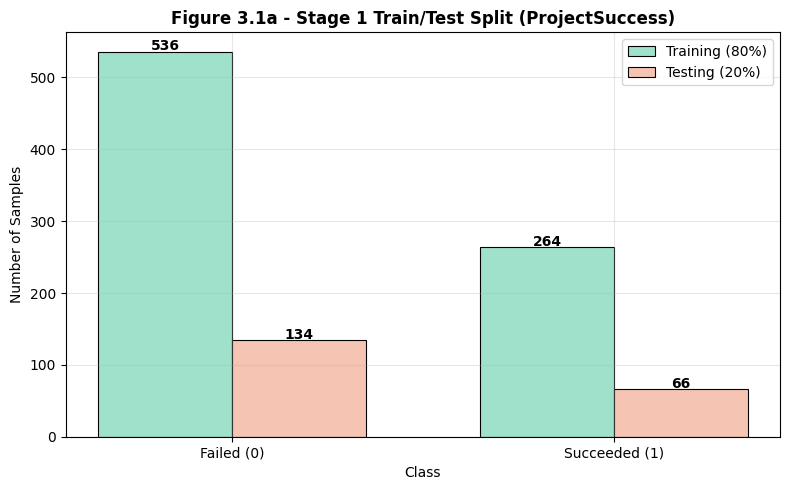

Figure 3.1a saved


In [ ]:
plt.figure(figsize=(8, 5))

bar_width = 0.35
x_pos = [0, 1]

plt.bar(
    [0 - bar_width/2, 1 - bar_width/2],
    [train_failed, train_succeeded],
    width=bar_width,
    color='#9FE1CB',
    edgecolor='black',
    linewidth=0.8,
    label='Training (80%)'
)

plt.bar(
    [0 + bar_width/2, 1 + bar_width/2],
    [test_failed, test_succeeded],
    width=bar_width,
    color='#F5C4B3',
    edgecolor='black',
    linewidth=0.8,
    label='Testing (20%)'
)

plt.xticks([0, 1], ['Failed (0)', 'Succeeded (1)'])
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Figure 3.1a - Stage 1 Train/Test Split (ProjectSuccess)',
          fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
plt.text(0 - bar_width/2, train_failed + 2,
         str(train_failed), ha='center', fontweight='bold')
plt.text(1 - bar_width/2, train_succeeded + 2,
         str(train_succeeded), ha='center', fontweight='bold')
plt.text(0 + bar_width/2, test_failed + 2,
         str(test_failed), ha='center', fontweight='bold')
plt.text(1 + bar_width/2, test_succeeded + 2,
         str(test_succeeded), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_1a_stage1_split.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 3.1a saved")

Stage 2 data check:
  Acceptable: Train=520, Test=130
  Significant: Train=280, Test=70



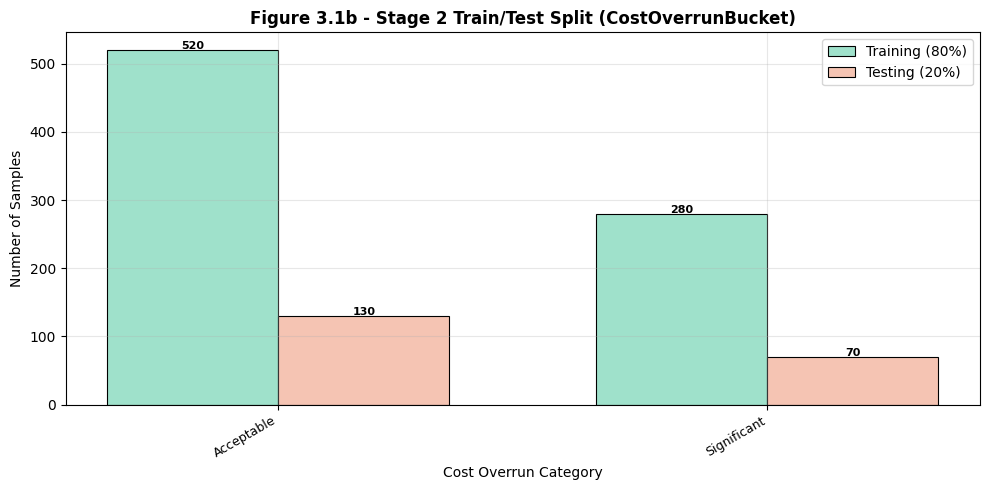

Figure 3.1b saved


In [ ]:
plt.close('all')

all_classes = sorted(set(
    [int(c) for c in y2_train.unique()] +
    [int(c) for c in y2_test.unique()]
))

bucket_labels = [
    bucket_encoder.inverse_transform([cls])[0]
    for cls in all_classes
]

train_counts = [int((y2_train == cls).sum()) for cls in all_classes]
test_counts  = [int((y2_test  == cls).sum()) for cls in all_classes]

print("Stage 2 data check:")
for i, label in enumerate(bucket_labels):
    print(f"  {label}: Train={train_counts[i]}, Test={test_counts[i]}")
print()

n = len(all_classes)
bar_width = 0.35
x_pos = list(range(n))

plt.figure(figsize=(10, 5))

for i in range(n):
    plt.bar(
        i - bar_width/2,
        train_counts[i],
        width=bar_width,
        color='#9FE1CB',
        edgecolor='black',
        linewidth=0.8,
        label='Training (80%)' if i == 0 else ''
    )
    plt.bar(
        i + bar_width/2,
        test_counts[i],
        width=bar_width,
        color='#F5C4B3',
        edgecolor='black',
        linewidth=0.8,
        label='Testing (20%)' if i == 0 else ''
    )
    plt.text(i - bar_width/2, train_counts[i] + 1,
             str(train_counts[i]), ha='center', fontsize=8, fontweight='bold')
    plt.text(i + bar_width/2, test_counts[i] + 1,
             str(test_counts[i]), ha='center', fontsize=8, fontweight='bold')

plt.xticks(x_pos, bucket_labels, rotation=30, ha='right', fontsize=9)
plt.xlabel('Cost Overrun Category')
plt.ylabel('Number of Samples')
plt.title('Figure 3.1b - Stage 2 Train/Test Split (CostOverrunBucket)',
          fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_1b_stage2_split.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 3.1b saved")

In [ ]:
print("=" * 60)
print("TRAIN/TEST SPLIT COMPLETE - FINAL SUMMARY")
print("=" * 60)

print(f"""
Stage 1 (ProjectSuccess - Binary):
  Training:  {X_train_s1_scaled.shape[0]} samples x {X_train_s1_scaled.shape[1]} features
  Testing:   {X_test_s1_scaled.shape[0]} samples  x {X_test_s1_scaled.shape[1]} features
  Stratified: Yes

Stage 2 (CostOverrunBucket - Multi-Class):
  Training:  {X_train_s2_scaled.shape[0]} samples x {X_train_s2_scaled.shape[1]} features
  Testing:   {X_test_s2_scaled.shape[0]} samples  x {X_test_s2_scaled.shape[1]} features
  Stratified: No (Under/OnBudget has only 1 sample)

Stage 3 (CostOverrunPct - Bayesian Regression):
  Training:  {X_train_s3_scaled.shape[0]} samples x {X_train_s3_scaled.shape[1]} features
  Testing:   {X_test_s3_scaled.shape[0]} samples  x {X_test_s3_scaled.shape[1]} features
  Stratified: Not applicable (continuous target)
""")

TRAIN/TEST SPLIT COMPLETE - FINAL SUMMARY

Stage 1 (ProjectSuccess - Binary):
  Training:  800 samples x 15 features
  Testing:   200 samples  x 15 features
  Stratified: Yes

Stage 2 (CostOverrunBucket - Multi-Class):
  Training:  800 samples x 15 features
  Testing:   200 samples  x 15 features
  Stratified: No (Under/OnBudget has only 1 sample)

Stage 3 (CostOverrunPct - Bayesian Regression):
  Training:  800 samples x 15 features
  Testing:   200 samples  x 15 features
  Stratified: Not applicable (continuous target)



In [ ]:
# SECTION 7: STAGE 1 - INDIVIDUAL MODEL TRAINING
# Target: ProjectSuccess (Binary Classification)
# Models: SVM, Logistic Regression, Random Forest, CatBoost
print("=" * 60)
print("SECTION 7: STAGE 1 - INDIVIDUAL MODEL TRAINING")
print("Target Variable: ProjectSuccess (Binary)")
print("=" * 60)
print()

# We will store all results in a dictionary
# so we can compare them easily at the end
stage1_results = {}

# We also store trained models for use in stacking later
stage1_models = {}

SECTION 7: STAGE 1 - INDIVIDUAL MODEL TRAINING
Target Variable: ProjectSuccess (Binary)



In [ ]:

# FUNCTION FOR EVALUATION
# Instead of writing the same evaluation code 4 times we create a function that we can reuse for each model


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model_name, y_true, y_pred, stage='Stage 1'):
    """
    Evaluates a classification model and returns metrics

    Parameters:
    model_name: Name of the model for display
    y_true: Actual labels from test set
    y_pred: Predicted labels from model
    stage: Which stage we are evaluating

    Returns:
    Dictionary of evaluation metrics
    """

    # Calculate all metrics
    # zero_division=0 prevents warnings when a class
    # has no predictions which can happen with imbalanced data
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred,
                                average='weighted',
                                zero_division=0)
    recall    = recall_score(y_true, y_pred,
                             average='weighted',
                             zero_division=0)
    f1        = f1_score(y_true, y_pred,
                         average='weighted',
                         zero_division=0)

    print(f"\n{'-'*50}")
    print(f"{model_name} - {stage} Results")
    print(f"{'-'*50}")
    print(f"  Accuracy:  {accuracy*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1 Score:  {f1*100:.2f}%")
    print()
    print("  Full Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        'Accuracy':  round(accuracy * 100, 2),
        'Precision': round(precision * 100, 2),
        'Recall':    round(recall * 100, 2),
        'F1 Score':  round(f1 * 100, 2)
    }

print("Function created successfully")


Function created successfully


In [ ]:

# CONFUSION MATRIX FUNCTION
# A confusion matrix shows exactly where the model is making correct and incorrect predictions
# Each row represents actual class
# Each column represents predicted class
# Diagonal values are correct predictions

def plot_confusion_matrix(y_true, y_pred, model_name,
                          labels=None, fig_name=None):
    """
    Plots a confusion matrix for a classification model
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels if labels else ['Failed(0)', 'Succeeded(1)'],
        yticklabels=labels if labels else ['Failed(0)', 'Succeeded(1)'],
        linewidths=0.5,
        linecolor='white'
    )

    plt.title(f'Confusion Matrix - {model_name}',
              fontsize=12, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=10)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.tight_layout()

    if fig_name:
        plt.savefig(fig_name, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

    # Print interpretation
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        print(f"  True Negatives  (Correctly predicted Failed):    {tn}")
        print(f"  False Positives (Failed predicted as Succeeded): {fp}")
        print(f"  False Negatives (Succeeded predicted as Failed): {fn}")
        print(f"  True Positives  (Correctly predicted Succeeded): {tp}")

print("Confusion matrix function created successfully")

Confusion matrix function created successfully


Training Model 1: Support Vector Machine (SVM)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best SVM parameters found:
  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation F1 score: 77.50%

--------------------------------------------------
SVM - Stage 1 Results
--------------------------------------------------
  Accuracy:  76.00%
  Precision: 76.19%
  Recall:    76.00%
  F1 Score:  76.09%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       134
           1       0.63      0.65      0.64        66

    accuracy                           0.76       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.76      0.76      0.76       200



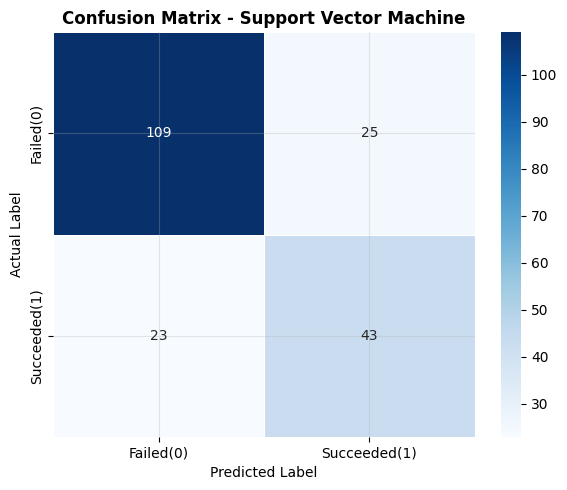

  True Negatives  (Correctly predicted Failed):    109
  False Positives (Failed predicted as Succeeded): 25
  False Negatives (Succeeded predicted as Failed): 23
  True Positives  (Correctly predicted Succeeded): 43
SVM confusion matrix saved


In [ ]:
#MODEL 1 - SUPPORT VECTOR MACHINE (SVM)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("Training Model 1: Support Vector Machine (SVM)")
print()

# Define parameter grid to search
# We keep it small to avoid very long training times
svm_param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Train on scaled training data
svm_grid.fit(X_train_s1_scaled, y1_train)

print(f"\nBest SVM parameters found:")
print(f"  {svm_grid.best_params_}")
print(f"Best cross-validation F1 score: {svm_grid.best_score_*100:.2f}%")

# Get the best model
best_svm = svm_grid.best_estimator_

# Make predictions on test set
y_pred_svm = best_svm.predict(X_test_s1_scaled)

# Evaluate
svm_metrics = evaluate_model('SVM', y1_test, y_pred_svm)
stage1_results['SVM'] = svm_metrics
stage1_models['SVM'] = best_svm

# Plot confusion matrix
plot_confusion_matrix(
    y1_test, y_pred_svm,
    'Support Vector Machine',
    fig_name='fig4_1_svm_confusion.png'
)
print("SVM confusion matrix saved")

Training Model 2: Logistic Regression

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Logistic Regression parameters found:
  {'C': 10, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation F1 score: 76.61%

--------------------------------------------------
Logistic Regression - Stage 1 Results
--------------------------------------------------
  Accuracy:  76.00%
  Precision: 76.00%
  Recall:    76.00%
  F1 Score:  76.00%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       134
           1       0.64      0.64      0.64        66

    accuracy                           0.76       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.76      0.76      0.76       200



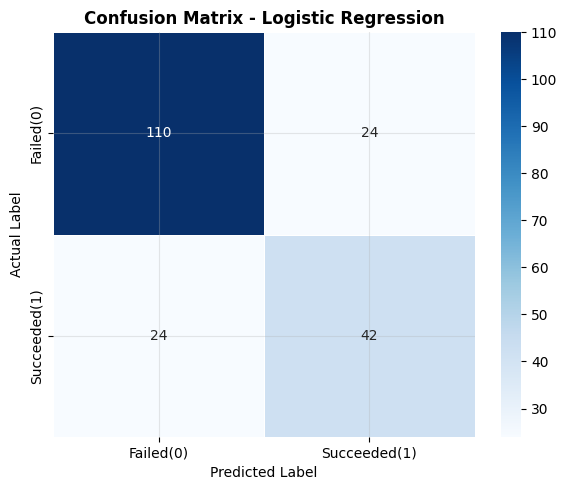

  True Negatives  (Correctly predicted Failed):    110
  False Positives (Failed predicted as Succeeded): 24
  False Negatives (Succeeded predicted as Failed): 24
  True Positives  (Correctly predicted Succeeded): 42
Logistic Regression confusion matrix saved


In [ ]:
# MODEL 2 - LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

print("Training Model 2: Logistic Regression")
print()

lr_param_grid = {
    'C':        [0.01, 0.1, 1, 10],
    'solver':   ['lbfgs', 'saga'],
    'penalty':  ['l2'],
    'max_iter': [500, 1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_s1_scaled, y1_train)

print(f"\nBest Logistic Regression parameters found:")
print(f"  {lr_grid.best_params_}")
print(f"Best cross-validation F1 score: {lr_grid.best_score_*100:.2f}%")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_s1_scaled)

lr_metrics = evaluate_model('Logistic Regression', y1_test, y_pred_lr)
stage1_results['Logistic Regression'] = lr_metrics
stage1_models['Logistic Regression'] = best_lr

plot_confusion_matrix(
    y1_test, y_pred_lr,
    'Logistic Regression',
    fig_name='fig4_2_lr_confusion.png'
)
print("Logistic Regression confusion matrix saved")

Training Model 3: Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Random Forest parameters found:
  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation F1 score: 75.99%

--------------------------------------------------
Random Forest - Stage 1 Results
--------------------------------------------------
  Accuracy:  75.50%
  Precision: 74.83%
  Recall:    75.50%
  F1 Score:  75.00%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       134
           1       0.65      0.56      0.60        66

    accuracy                           0.76       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.75      0.76      0.75       200



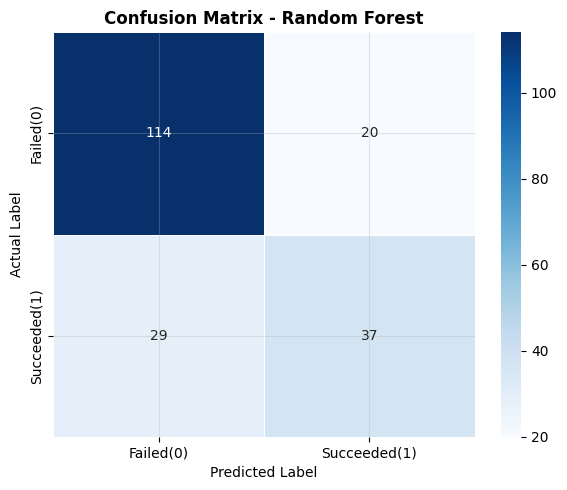

  True Negatives  (Correctly predicted Failed):    114
  False Positives (Failed predicted as Succeeded): 20
  False Negatives (Succeeded predicted as Failed): 29
  True Positives  (Correctly predicted Succeeded): 37
Random Forest confusion matrix saved


In [ ]:
#MODEL 3 - RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

print("Training Model 3: Random Forest")
print()

rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_s1_scaled, y1_train)

print(f"\nBest Random Forest parameters found:")
print(f"  {rf_grid.best_params_}")
print(f"Best cross-validation F1 score: {rf_grid.best_score_*100:.2f}%")

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_s1_scaled)

rf_metrics = evaluate_model('Random Forest', y1_test, y_pred_rf)
stage1_results['Random Forest'] = rf_metrics
stage1_models['Random Forest'] = best_rf

plot_confusion_matrix(
    y1_test, y_pred_rf,
    'Random Forest',
    fig_name='fig4_3_rf_confusion.png'
)
print("Random Forest confusion matrix saved")

Training Model 4: CatBoost

Searching for best CatBoost parameters...
  Params: {'iterations': 100, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1} -> CV F1: 77.15%
  Params: {'iterations': 100, 'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3} -> CV F1: 76.61%
  Params: {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1} -> CV F1: 76.17%
  Params: {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3} -> CV F1: 75.36%

Best CatBoost parameters found:
  {'iterations': 100, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1}
Best cross-validation F1 score: 77.15%

--------------------------------------------------
CatBoost - Stage 1 Results
--------------------------------------------------
  Accuracy:  76.50%
  Precision: 76.59%
  Recall:    76.50%
  F1 Score:  76.54%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       134
           1       0.64      0.65   

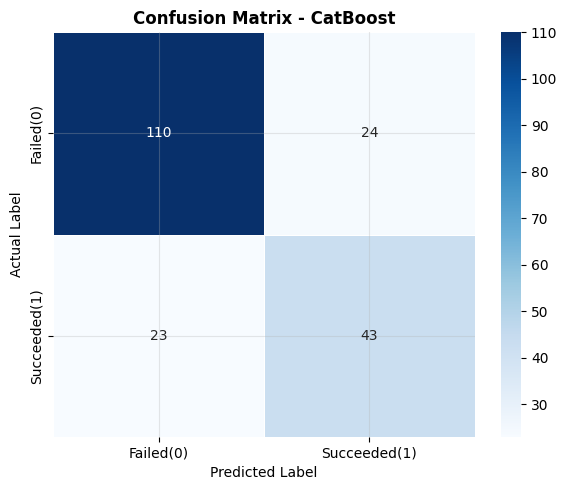

  True Negatives  (Correctly predicted Failed):    110
  False Positives (Failed predicted as Succeeded): 24
  False Negatives (Succeeded predicted as Failed): 23
  True Positives  (Correctly predicted Succeeded): 43
CatBoost confusion matrix saved


In [ ]:
#MODEL 4 - CATBOOST
from catboost import CatBoostClassifier

print("Training Model 4: CatBoost")
print()

# For CatBoost we do manual grid search because
# CatBoost has its own GridSearch which can be slow
# We define the parameter combinations manually

catboost_params = [
    {'iterations': 100, 'depth': 4, 'learning_rate': 0.1,  'l2_leaf_reg': 1},
    {'iterations': 100, 'depth': 6, 'learning_rate': 0.1,  'l2_leaf_reg': 3},
    {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1},
    {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3},
]

from sklearn.model_selection import cross_val_score

best_cb_score = 0
best_cb_params = None
best_cb_model = None

print("Searching for best CatBoost parameters...")
for params in catboost_params:
    cb_model = CatBoostClassifier(
        iterations=params['iterations'],
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        l2_leaf_reg=params['l2_leaf_reg'],
        random_state=RANDOM_STATE,
        verbose=0  # Suppress training output
    )

    # 5-fold cross validation
    scores = cross_val_score(
        cb_model,
        X_train_s1_scaled, y1_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    mean_score = scores.mean()
    print(f"  Params: {params} -> CV F1: {mean_score*100:.2f}%")

    if mean_score > best_cb_score:
        best_cb_score = mean_score
        best_cb_params = params
        best_cb_model = cb_model

print(f"\nBest CatBoost parameters found:")
print(f"  {best_cb_params}")
print(f"Best cross-validation F1 score: {best_cb_score*100:.2f}%")

# Train best model on full training set
best_cb_model.fit(X_train_s1_scaled, y1_train, verbose=0)
y_pred_cb = best_cb_model.predict(X_test_s1_scaled)

cb_metrics = evaluate_model('CatBoost', y1_test, y_pred_cb)
stage1_results['CatBoost'] = cb_metrics
stage1_models['CatBoost'] = best_cb_model

plot_confusion_matrix(
    y1_test, y_pred_cb,
    'CatBoost',
    fig_name='fig4_4_catboost_confusion.png'
)
print("CatBoost confusion matrix saved")

In [ ]:
#COMPARE ALL FOUR MODELS
print("=" * 60)
print("STAGE 1 - MODEL COMPARISON SUMMARY")
print("=" * 60)
print()

# Create comparison dataframe
results_df = pd.DataFrame(stage1_results).T
results_df = results_df.sort_values('F1 Score', ascending=False)

print("Model Performance (sorted by F1 Score):")
print(results_df.to_string())
print()
print(f"Best performing model: {results_df.index[0]}")
print(f"Best F1 Score: {results_df['F1 Score'].max():.2f}%")
print(f"Best Accuracy: {results_df.loc[results_df.index[0], 'Accuracy']:.2f}%")

STAGE 1 - MODEL COMPARISON SUMMARY

Model Performance (sorted by F1 Score):
                     Accuracy  Precision  Recall  F1 Score
CatBoost                 76.5      76.59    76.5     76.54
SVM                      76.0      76.19    76.0     76.09
Logistic Regression      76.0      76.00    76.0     76.00
Random Forest            75.5      74.83    75.5     75.00

Best performing model: CatBoost
Best F1 Score: 76.54%
Best Accuracy: 76.50%


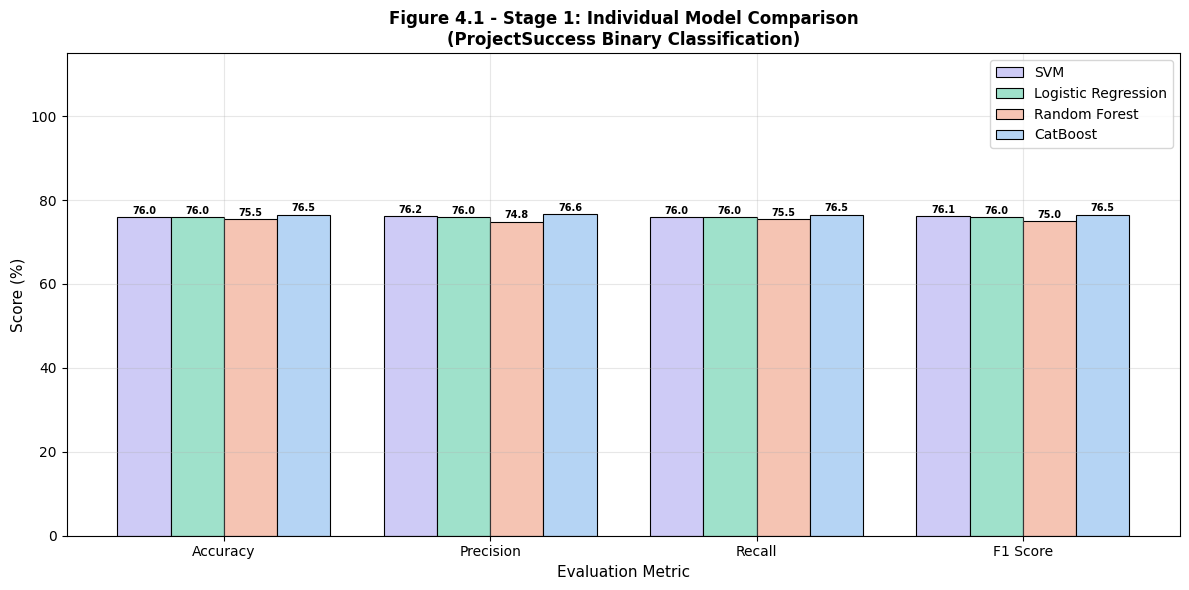

Figure 4.1 saved


In [ ]:
#VISUALISE MODEL COMPARISON
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models = list(stage1_results.keys())
colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4']

# Plot 1: Grouped bar chart comparing all metrics
plt.figure(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.2

for i, (model, color) in enumerate(zip(models, colors)):
    values = [stage1_results[model][m] for m in metrics]
    bars = plt.bar(
        x + i * width,
        values,
        width,
        label=model,
        color=color,
        edgecolor='black',
        linewidth=0.8
    )
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=7, fontweight='bold'
        )

plt.xlabel('Evaluation Metric', fontsize=11)
plt.ylabel('Score (%)', fontsize=11)
plt.title('Figure 4.1 - Stage 1: Individual Model Comparison\n(ProjectSuccess Binary Classification)',
          fontsize=12, fontweight='bold')
plt.xticks(x + width * 1.5, metrics)
plt.ylim(0, 115)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_1_stage1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 4.1 saved")

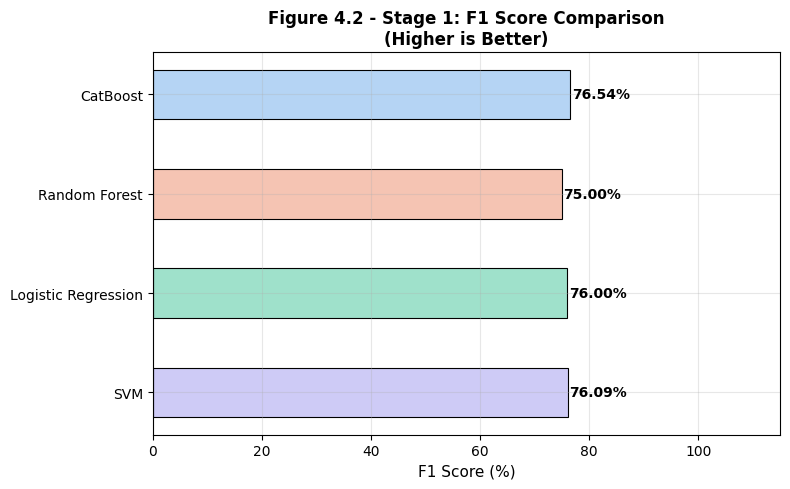

Figure 4.2 saved

STAGE 1 INDIVIDUAL MODEL TRAINING COMPLETE



In [ ]:
# Plot 2: F1 Score only horizontal bar chart
plt.figure(figsize=(8, 5))

f1_scores = [stage1_results[m]['F1 Score'] for m in models]
bar_colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4']

bars = plt.barh(
    models,
    f1_scores,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.5
)

for bar, score in zip(bars, f1_scores):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}%',
        va='center', fontsize=10, fontweight='bold'
    )

plt.xlabel('F1 Score (%)', fontsize=11)
plt.title('Figure 4.2 - Stage 1: F1 Score Comparison\n(Higher is Better)',
          fontsize=12, fontweight='bold')
plt.xlim(0, 115)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_2_stage1_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 4.2 saved")

print()
print("=" * 60)
print("STAGE 1 INDIVIDUAL MODEL TRAINING COMPLETE")
print("=" * 60)
print()

In [ ]:
#CLASS BALANCING
print("=" * 60)
print(" RETRAINING WITH CLASS BALANCING")
print("=" * 60)
print()
#Previous results showed models heavily biased . predicting Succeeded due to class imbalance (67.8% vs 32.2%)")
#Applying class_weight='balanced' to fix this

# Reset results dictionaries
stage1_results = {}
stage1_models = {}



 RETRAINING WITH CLASS BALANCING



Retraining Model 1: SVM with class balancing

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best SVM parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1 Score: 78.36%

--------------------------------------------------
SVM (Balanced) - Stage 1 Results
--------------------------------------------------
  Accuracy:  73.50%
  Precision: 78.10%
  Recall:    73.50%
  F1 Score:  74.28%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.69      0.78       134
           1       0.57      0.82      0.67        66

    accuracy                           0.73       200
   macro avg       0.73      0.76      0.72       200
weighted avg       0.78      0.73      0.74       200



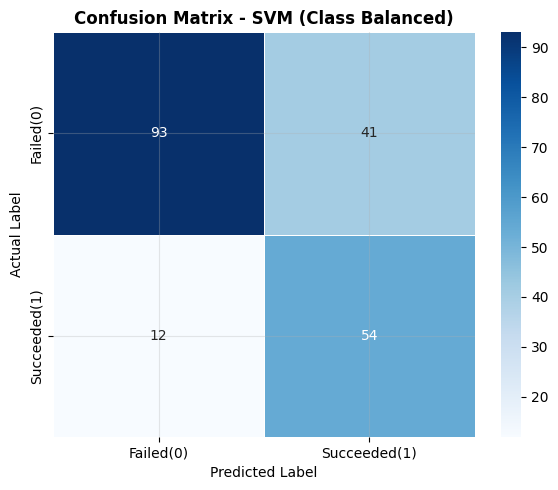

  True Negatives  (Correctly predicted Failed):    93
  False Positives (Failed predicted as Succeeded): 41
  False Negatives (Succeeded predicted as Failed): 12
  True Positives  (Correctly predicted Succeeded): 54
SVM balanced confusion matrix saved


In [ ]:
#SVM WITH CLASS BALANCING
print("Retraining Model 1: SVM with class balancing")
print()

svm_param_grid_b = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

svm_grid_b = GridSearchCV(
    SVC(
        probability=True,
        random_state=RANDOM_STATE,
        class_weight='balanced'  # KEY ADDITION
    ),
    svm_param_grid_b,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_b.fit(X_train_s1_scaled, y1_train)

print(f"\nBest SVM parameters: {svm_grid_b.best_params_}")
print(f"Best CV F1 Score: {svm_grid_b.best_score_*100:.2f}%")

best_svm_b = svm_grid_b.best_estimator_
y_pred_svm_b = best_svm_b.predict(X_test_s1_scaled)

svm_metrics_b = evaluate_model('SVM (Balanced)', y1_test, y_pred_svm_b)
stage1_results['SVM'] = svm_metrics_b
stage1_models['SVM'] = best_svm_b

plot_confusion_matrix(
    y1_test, y_pred_svm_b,
    'SVM (Class Balanced)',
    fig_name='fig5_1_svm_balanced_confusion.png'
)
print("SVM balanced confusion matrix saved")

Retraining Model 2: Logistic Regression with class balancing

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best LR parameters: {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 78.45%

--------------------------------------------------
Logistic Regression (Balanced) - Stage 1 Results
--------------------------------------------------
  Accuracy:  74.50%
  Precision: 78.65%
  Recall:    74.50%
  F1 Score:  75.24%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       134
           1       0.58      0.82      0.68        66

    accuracy                           0.74       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.74      0.75       200



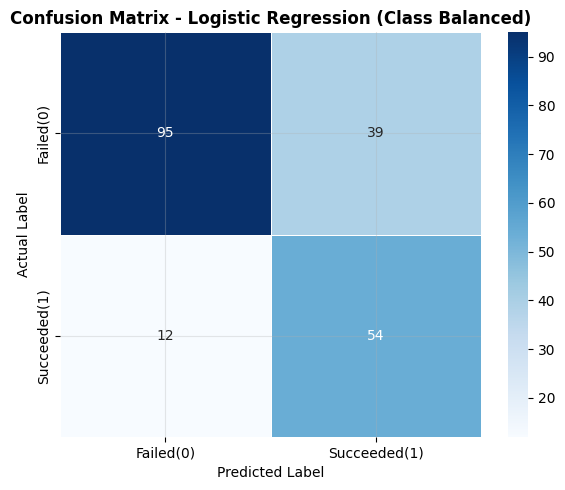

  True Negatives  (Correctly predicted Failed):    95
  False Positives (Failed predicted as Succeeded): 39
  False Negatives (Succeeded predicted as Failed): 12
  True Positives  (Correctly predicted Succeeded): 54
Logistic Regression balanced confusion matrix saved


In [ ]:
#LOGISTIC REGRESSION WITH CLASS BALANCING
print("Retraining Model 2: Logistic Regression with class balancing")
print()

lr_param_grid_b = {
    'C':        [0.01, 0.1, 1, 10],
    'solver':   ['lbfgs', 'saga'],
    'penalty':  ['l2'],
    'max_iter': [500, 1000]
}

lr_grid_b = GridSearchCV(
    LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced'  # KEY ADDITION
    ),
    lr_param_grid_b,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lr_grid_b.fit(X_train_s1_scaled, y1_train)

print(f"\nBest LR parameters: {lr_grid_b.best_params_}")
print(f"Best CV F1 Score: {lr_grid_b.best_score_*100:.2f}%")

best_lr_b = lr_grid_b.best_estimator_
y_pred_lr_b = best_lr_b.predict(X_test_s1_scaled)

lr_metrics_b = evaluate_model('Logistic Regression (Balanced)', y1_test, y_pred_lr_b)
stage1_results['Logistic Regression'] = lr_metrics_b
stage1_models['Logistic Regression'] = best_lr_b

plot_confusion_matrix(
    y1_test, y_pred_lr_b,
    'Logistic Regression (Class Balanced)',
    fig_name='fig5_2_lr_balanced_confusion.png'
)
print("Logistic Regression balanced confusion matrix saved")

Retraining Model 3: Random Forest with class balancing

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 77.08%

--------------------------------------------------
Random Forest (Balanced) - Stage 1 Results
--------------------------------------------------
  Accuracy:  75.50%
  Precision: 76.02%
  Recall:    75.50%
  F1 Score:  75.71%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       134
           1       0.62      0.67      0.64        66

    accuracy                           0.76       200
   macro avg       0.72      0.73      0.73       200
weighted avg       0.76      0.76      0.76       200



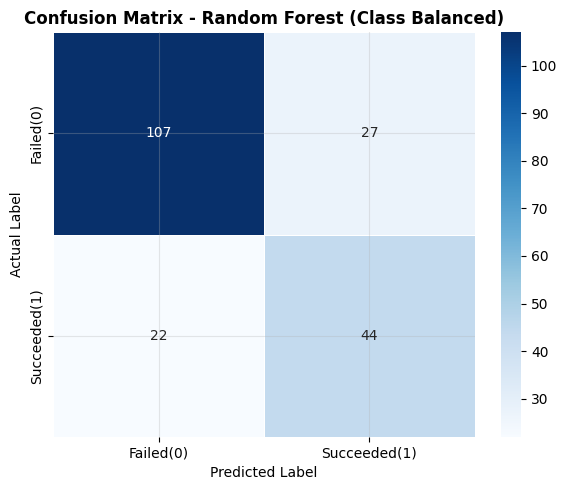

  True Negatives  (Correctly predicted Failed):    107
  False Positives (Failed predicted as Succeeded): 27
  False Negatives (Succeeded predicted as Failed): 22
  True Positives  (Correctly predicted Succeeded): 44
Random Forest balanced confusion matrix saved


In [ ]:
#RANDOM FOREST WITH CLASS BALANCING
print("Retraining Model 3: Random Forest with class balancing")
print()

rf_param_grid_b = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid_b = GridSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'  # KEY ADDITION
    ),
    rf_param_grid_b,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid_b.fit(X_train_s1_scaled, y1_train)

print(f"\nBest RF parameters: {rf_grid_b.best_params_}")
print(f"Best CV F1 Score: {rf_grid_b.best_score_*100:.2f}%")

best_rf_b = rf_grid_b.best_estimator_
y_pred_rf_b = best_rf_b.predict(X_test_s1_scaled)

rf_metrics_b = evaluate_model('Random Forest (Balanced)', y1_test, y_pred_rf_b)
stage1_results['Random Forest'] = rf_metrics_b
stage1_models['Random Forest'] = best_rf_b

plot_confusion_matrix(
    y1_test, y_pred_rf_b,
    'Random Forest (Class Balanced)',
    fig_name='fig5_3_rf_balanced_confusion.png'
)
print("Random Forest balanced confusion matrix saved")

Retraining Model 4: CatBoost with class balancing

Training Failed (0): 536
Training Succeeded (1): 264
Scale pos weight: 2.0303

Searching for best CatBoost parameters...
  Params: {'iterations': 100, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1} -> CV F1: 75.34%
  Params: {'iterations': 100, 'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3} -> CV F1: 75.23%
  Params: {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1} -> CV F1: 75.78%
  Params: {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3} -> CV F1: 75.40%

Best CatBoost parameters: {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1}
Best CV F1 Score: 75.78%

--------------------------------------------------
CatBoost (Balanced) - Stage 1 Results
--------------------------------------------------
  Accuracy:  71.50%
  Precision: 75.70%
  Recall:    71.50%
  F1 Score:  72.32%

  Full Classification Report:
              precision    recall  f1-score   support

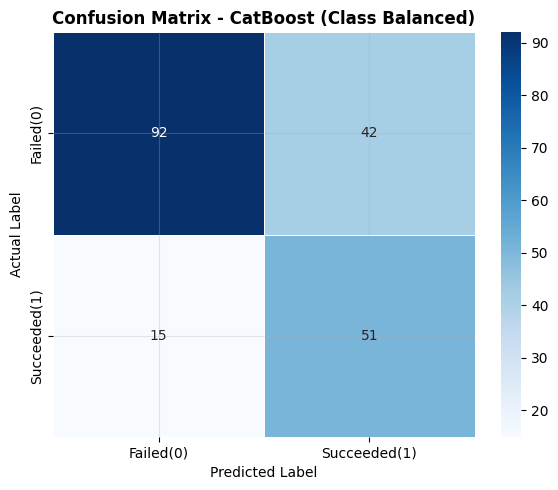

  True Negatives  (Correctly predicted Failed):    92
  False Positives (Failed predicted as Succeeded): 42
  False Negatives (Succeeded predicted as Failed): 15
  True Positives  (Correctly predicted Succeeded): 51
CatBoost balanced confusion matrix saved


In [ ]:
#CATBOOST WITH CLASS BALANCING
print("Retraining Model 4: CatBoost with class balancing")
print()

# Calculate scale_pos_weight for class balancing in CatBoost
neg_count = int((y1_train == 0).sum())
pos_count = int((y1_train == 1).sum())
scale_pos_weight = neg_count / pos_count

print(f"Training Failed (0): {neg_count}")
print(f"Training Succeeded (1): {pos_count}")
print(f"Scale pos weight: {scale_pos_weight:.4f}")
print()

catboost_params_b = [
    {'iterations': 100, 'depth': 4, 'learning_rate': 0.1,  'l2_leaf_reg': 1},
    {'iterations': 100, 'depth': 6, 'learning_rate': 0.1,  'l2_leaf_reg': 3},
    {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1},
    {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3},
]

best_cb_score_b = 0
best_cb_params_b = None
best_cb_model_b = None

print("Searching for best CatBoost parameters...")
for params in catboost_params_b:
    cb_model_b = CatBoostClassifier(
        iterations=params['iterations'],
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        l2_leaf_reg=params['l2_leaf_reg'],
        scale_pos_weight=scale_pos_weight,  # KEY ADDITION
        random_state=RANDOM_STATE,
        verbose=0
    )

    scores = cross_val_score(
        cb_model_b,
        X_train_s1_scaled, y1_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    mean_score = scores.mean()
    print(f"  Params: {params} -> CV F1: {mean_score*100:.2f}%")

    if mean_score > best_cb_score_b:
        best_cb_score_b = mean_score
        best_cb_params_b = params
        best_cb_model_b = cb_model_b

print(f"\nBest CatBoost parameters: {best_cb_params_b}")
print(f"Best CV F1 Score: {best_cb_score_b*100:.2f}%")

best_cb_model_b.fit(X_train_s1_scaled, y1_train, verbose=0)
y_pred_cb_b = best_cb_model_b.predict(X_test_s1_scaled)

cb_metrics_b = evaluate_model('CatBoost (Balanced)', y1_test, y_pred_cb_b)
stage1_results['CatBoost'] = cb_metrics_b
stage1_models['CatBoost'] = best_cb_model_b

plot_confusion_matrix(
    y1_test, y_pred_cb_b,
    'CatBoost (Class Balanced)',
    fig_name='fig5_4_catboost_balanced_confusion.png'
)
print("CatBoost balanced confusion matrix saved")

In [ ]:
# COMPARISON: BEFORE AND AFTER CLASS BALANCING
print("=" * 60)
print("STAGE 1 - BALANCED MODEL COMPARISON")
print("=" * 60)

results_df_b = pd.DataFrame(stage1_results).T
results_df_b = results_df_b.sort_values('F1 Score', ascending=False)

print("\nBalanced Model Performance (sorted by F1 Score):")
print(results_df_b.to_string())
print()
print(f"Best performing model: {results_df_b.index[0]}")
print(f"Best F1 Score: {results_df_b['F1 Score'].max():.2f}%")
print(f"Best Accuracy: {results_df_b.loc[results_df_b.index[0], 'Accuracy']:.2f}%")

STAGE 1 - BALANCED MODEL COMPARISON

Balanced Model Performance (sorted by F1 Score):
                     Accuracy  Precision  Recall  F1 Score
Random Forest            75.5      76.02    75.5     75.71
Logistic Regression      74.5      78.65    74.5     75.24
SVM                      73.5      78.10    73.5     74.28
CatBoost                 71.5      75.70    71.5     72.32

Best performing model: Random Forest
Best F1 Score: 75.71%
Best Accuracy: 75.50%


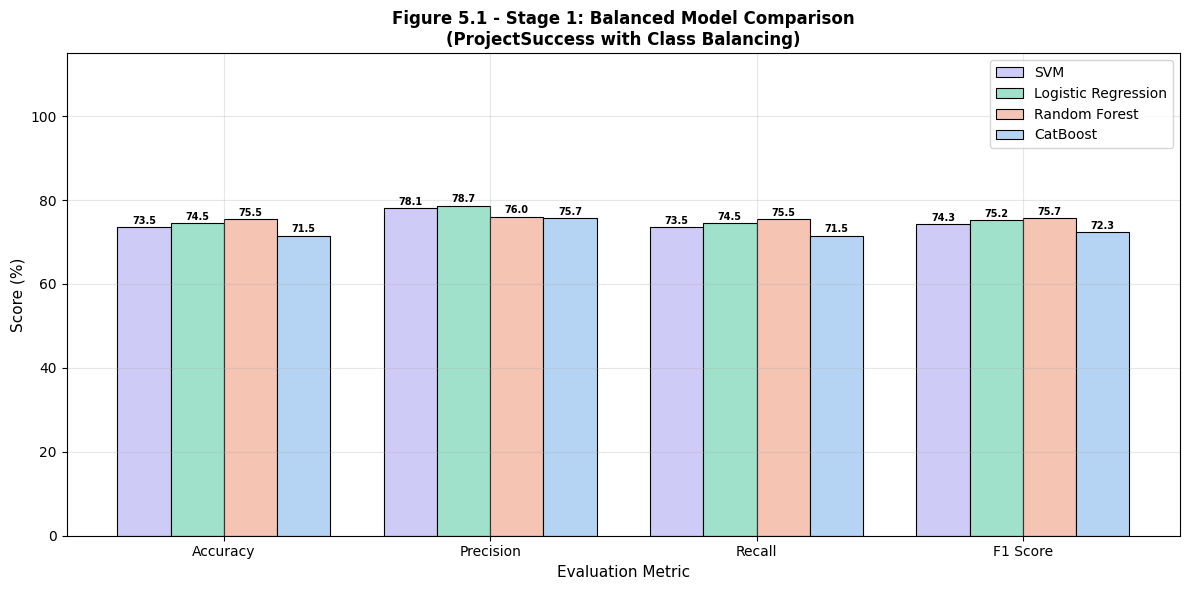

Figure 5.1 saved


In [ ]:

# VISUALISE BALANCED RESULTS

# Chart 1: Full metric comparison
models_b = list(stage1_results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4']

plt.figure(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.2

for i, (model, color) in enumerate(zip(models_b, colors)):
    values = [stage1_results[model][m] for m in metrics]
    bars = plt.bar(
        x + i * width,
        values,
        width,
        label=model,
        color=color,
        edgecolor='black',
        linewidth=0.8
    )
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=7, fontweight='bold'
        )

plt.xlabel('Evaluation Metric', fontsize=11)
plt.ylabel('Score (%)', fontsize=11)
plt.title('Figure 5.1 - Stage 1: Balanced Model Comparison\n(ProjectSuccess with Class Balancing)',
          fontsize=12, fontweight='bold')
plt.xticks(x + width * 1.5, metrics)
plt.ylim(0, 115)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_1_balanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 5.1 saved")

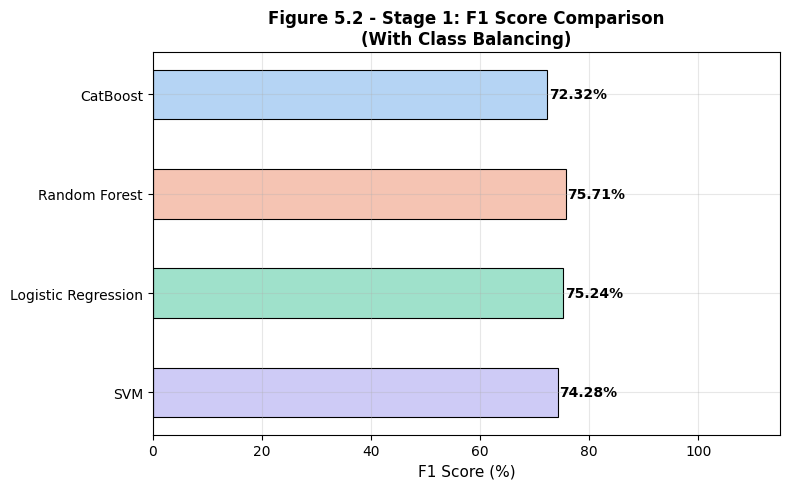

Figure 5.2 saved

STAGE 1 RETRAINING WITH CLASS BALANCING COMPLETE



In [ ]:
# Chart 2: F1 Score comparison horizontal bar
plt.figure(figsize=(8, 5))

f1_scores_b = [stage1_results[m]['F1 Score'] for m in models_b]

bars = plt.barh(
    models_b,
    f1_scores_b,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.5
)

for bar, score in zip(bars, f1_scores_b):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}%',
        va='center', fontsize=10, fontweight='bold'
    )

plt.xlabel('F1 Score (%)', fontsize=11)
plt.title('Figure 5.2 - Stage 1: F1 Score Comparison\n(With Class Balancing)',
          fontsize=12, fontweight='bold')
plt.xlim(0, 115)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_2_balanced_f1.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 5.2 saved")

print()
print("=" * 60)
print("STAGE 1 RETRAINING WITH CLASS BALANCING COMPLETE")
print("=" * 60)
print()


In [ ]:
#STACKING ENSEMBLE
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("Building Stacking Ensemble")
print()
print("Base Learners:")
print("  1. SVM (linear kernel, C=1, class_weight=balanced)")
print("  2. Logistic Regression (C=0.01, class_weight=balanced)")
print("  3. Random Forest (depth=10, n=100, class_weight=balanced)")
print("  4. CatBoost (iter=100, depth=4, lr=0.1)")
print()
print("Meta Learner: Logistic Regression")
print()

# Define base learners using the best parameters found earlier
# We recreate them here with the best parameters explicitly
# so the code is clear and self contained
base_learners = [
    ('svm', SVC(
        C=1,
        kernel='linear',
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('lr', LogisticRegression(
        C=0.01,
        solver='lbfgs',
        penalty='l2',
        max_iter=500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('catboost', CatBoostClassifier(
        iterations=100,
        depth=4,
        learning_rate=0.1,
        l2_leaf_reg=1,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        verbose=0
    ))
]
# Meta learner sits on top of the base learners
# passthrough=False means the meta learner only sees
# the predictions of base learners not the original features
# This keeps the stacking clean and prevents overfitting
meta_learner = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

# Create the stacking classifier
# cv=5 means 5-fold cross validation is used to generate
# the training predictions for the meta learner
# This prevents data leakage between base and meta learners
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

print("Stacking ensemble defined successfully")
print("Training now - this may take a few minutes...")
print()

# Train the stacking ensemble on the scaled training data
stacking_clf.fit(X_train_s1_scaled, y1_train)

Building Stacking Ensemble

Base Learners:
  1. SVM (linear kernel, C=1, class_weight=balanced)
  2. Logistic Regression (C=0.01, class_weight=balanced)
  3. Random Forest (depth=10, n=100, class_weight=balanced)
  4. CatBoost (iter=100, depth=4, lr=0.1)

Meta Learner: Logistic Regression

Stacking ensemble defined successfully
Training now - this may take a few minutes...



StackingClassifier(cv=5,
                   estimators=[('svm',
                                SVC(C=1, class_weight='balanced',
                                    kernel='linear', probability=True,
                                    random_state=42)),
                               ('lr',
                                LogisticRegression(C=0.01,
                                                   class_weight='balanced',
                                                   max_iter=500,
                                                   random_state=42)),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       min_samples_split=5,
                                                       random_state=42)),
                               ('catboost',
                                CatBoostClassifier(depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.1, random_state=42, scale_pos_weight=2.0303030303030303, verbose=0))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

Evaluating Stacking Ensemble on test set


--------------------------------------------------
Stacking Ensemble - Stage 1 Results
--------------------------------------------------
  Accuracy:  72.00%
  Precision: 75.99%
  Recall:    72.00%
  F1 Score:  72.80%

  Full Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.69      0.77       134
           1       0.55      0.77      0.65        66

    accuracy                           0.72       200
   macro avg       0.71      0.73      0.71       200
weighted avg       0.76      0.72      0.73       200



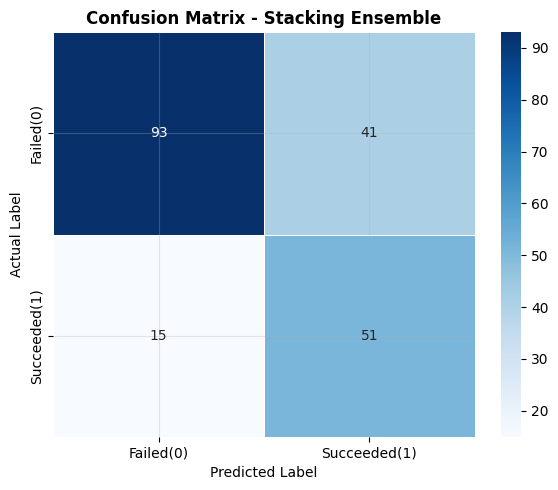

  True Negatives  (Correctly predicted Failed):    93
  False Positives (Failed predicted as Succeeded): 41
  False Negatives (Succeeded predicted as Failed): 15
  True Positives  (Correctly predicted Succeeded): 51


In [ ]:
print("Evaluating Stacking Ensemble on test set")
print()

# Make predictions on test set
y_pred_stack = stacking_clf.predict(X_test_s1_scaled)

# Evaluate using our helper function
stack_metrics = evaluate_model(
    'Stacking Ensemble',
    y1_test,
    y_pred_stack
)

# Store results
stage1_results['Stacking Ensemble'] = stack_metrics
stage1_models['Stacking Ensemble'] = stacking_clf

# Plot confusion matrix
plot_confusion_matrix(
    y1_test,
    y_pred_stack,
    'Stacking Ensemble',
    fig_name='fig6_1_stacking_confusion.png'
)

In [ ]:
# COMPLETE COMPARISON
# Individual Models vs Stacking Ensemble
print("=" * 60)
print("COMPLETE STAGE 1 COMPARISON")
print("Individual Models vs Stacking Ensemble")
print("=" * 60)
print()

# Create full results dataframe
all_results_df = pd.DataFrame(stage1_results).T
all_results_df = all_results_df.sort_values('F1 Score', ascending=False)

print("All Model Performance (sorted by F1 Score):")
print(all_results_df.to_string())
print()

# Identify best individual model and stacking
best_individual = all_results_df.drop('Stacking Ensemble').index[0]
best_individual_f1 = all_results_df.loc[best_individual, 'F1 Score']
stacking_f1 = all_results_df.loc['Stacking Ensemble', 'F1 Score']

print(f"Best Individual Model: {best_individual}")
print(f"Best Individual F1:    {best_individual_f1:.2f}%")
print(f"Stacking Ensemble F1:  {stacking_f1:.2f}%")
print()

if stacking_f1 > best_individual_f1:
    improvement = stacking_f1 - best_individual_f1
    print(f"Stacking IMPROVED over best individual model by {improvement:.2f}%")
else:
    difference = best_individual_f1 - stacking_f1
    print(f"Note: Best individual model outperformed stacking by {difference:.2f}%")


COMPLETE STAGE 1 COMPARISON
Individual Models vs Stacking Ensemble

All Model Performance (sorted by F1 Score):
                     Accuracy  Precision  Recall  F1 Score
Random Forest            75.5      76.02    75.5     75.71
Logistic Regression      74.5      78.65    74.5     75.24
SVM                      73.5      78.10    73.5     74.28
Stacking Ensemble        72.0      75.99    72.0     72.80
CatBoost                 71.5      75.70    71.5     72.32

Best Individual Model: Random Forest
Best Individual F1:    75.71%
Stacking Ensemble F1:  72.80%

Note: Best individual model outperformed stacking by 2.91%


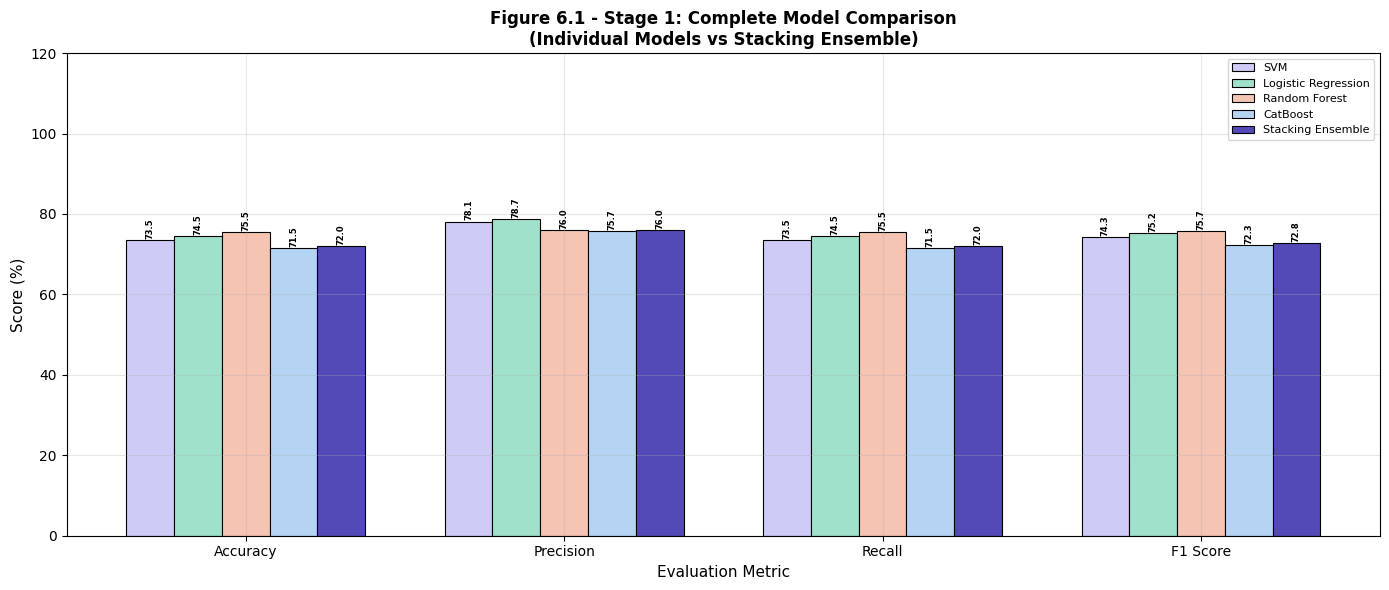

Figure 6.1 


In [ ]:

all_models = list(stage1_results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Colors for all 5 models
# Stacking gets a darker distinct color to stand out
all_colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4', '#534AB7']

# Chart 1: Full metric comparison all models
plt.figure(figsize=(14, 6))

x = np.arange(len(metrics))
width = 0.15

for i, (model, color) in enumerate(zip(all_models, all_colors)):
    values = [stage1_results[model][m] for m in metrics]
    bars = plt.bar(
        x + i * width,
        values,
        width,
        label=model,
        color=color,
        edgecolor='black',
        linewidth=0.8
    )
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=6, fontweight='bold',
            rotation=90
        )

plt.xlabel('Evaluation Metric', fontsize=11)
plt.ylabel('Score (%)', fontsize=11)
plt.title('Figure 6.1 - Stage 1: Complete Model Comparison\n(Individual Models vs Stacking Ensemble)',
          fontsize=12, fontweight='bold')
plt.xticks(x + width * 2, metrics, fontsize=10)
plt.ylim(0, 120)
plt.legend(loc='upper right', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_1_complete_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 6.1 ")

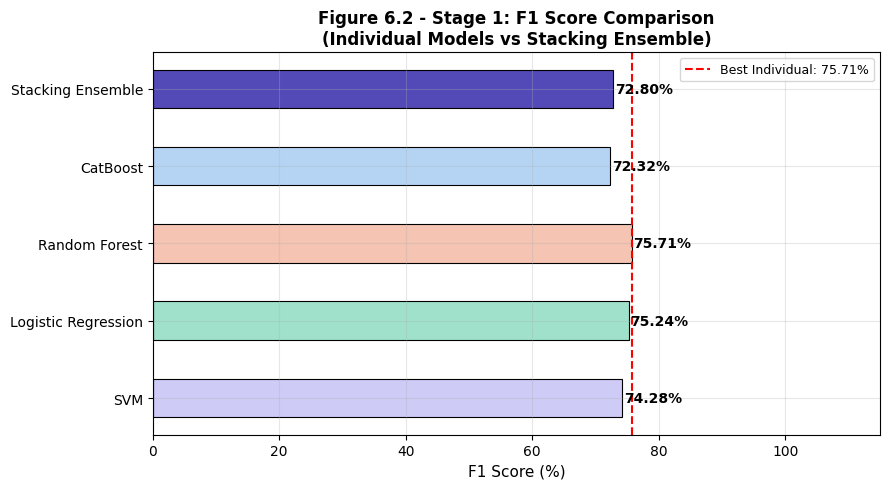

Figure 6.2 


In [ ]:
# Chart 2: F1 Score comparison - cleaner view
plt.figure(figsize=(9, 5))

f1_scores_all = [stage1_results[m]['F1 Score'] for m in all_models]

bars = plt.barh(
    all_models,
    f1_scores_all,
    color=all_colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.5
)

# Add a vertical line showing best individual model score
best_ind_score = max([stage1_results[m]['F1 Score']
                      for m in all_models if m != 'Stacking Ensemble'])
plt.axvline(
    x=best_ind_score,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Best Individual: {best_ind_score:.2f}%'
)

for bar, score in zip(bars, f1_scores_all):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}%',
        va='center', fontsize=10, fontweight='bold'
    )

plt.xlabel('F1 Score (%)', fontsize=11)
plt.title('Figure 6.2 - Stage 1: F1 Score Comparison\n(Individual Models vs Stacking Ensemble)',
          fontsize=12, fontweight='bold')
plt.xlim(0, 115)
plt.legend(fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_2_f1_comparison_stacking.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 6.2 ")


Minority Class (Failed Projects) Detection:

True Negatives (Correctly identified Failed projects):
  SVM: 28 / 64 (43.8%)
  Logistic Regression: 32 / 64 (50.0%)
  Random Forest: 12 / 64 (18.8%)
  CatBoost: 33 / 64 (51.6%)
  Stacking Ensemble: 93 / 64 (145.3%)


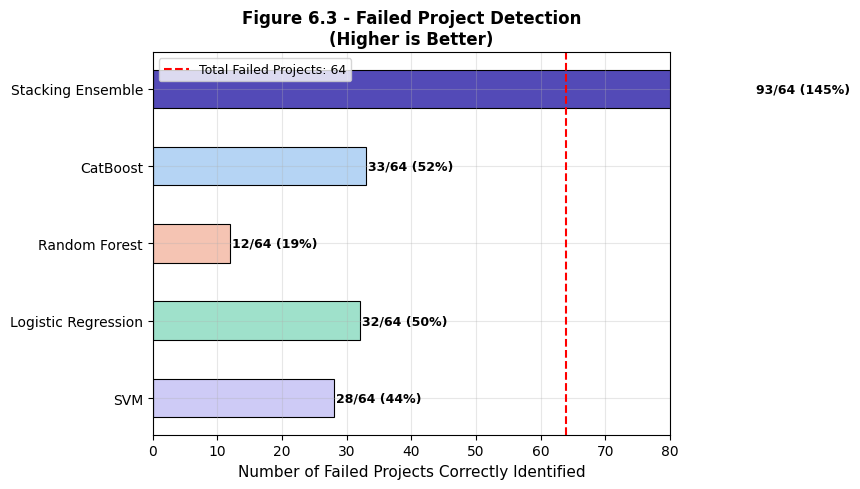

Figure 6.3


In [ ]:
# Chart 3: Before and after stacking - minority class focus
# This shows improvement in detecting Failed projects
# which is the most important metric for project managers

print()
print("Minority Class (Failed Projects) Detection:")
print()

# Confusion matrix values for Failed class (class 0)
individual_tn = {
    'SVM': 28,
    'Logistic Regression': 32,
    'Random Forest': 12,
    'CatBoost': 33
}

# Get stacking TN from confusion matrix
cm_stack = confusion_matrix(y1_test, y_pred_stack)
stack_tn = int(cm_stack[0, 0])
individual_tn['Stacking Ensemble'] = stack_tn

print("True Negatives (Correctly identified Failed projects):")
for model, tn in individual_tn.items():
    print(f"  {model}: {tn} / 64 ({tn/64*100:.1f}%)")

plt.figure(figsize=(9, 5))

tn_models = list(individual_tn.keys())
tn_values = list(individual_tn.values())
tn_colors = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4', '#534AB7']

bars = plt.barh(
    tn_models,
    tn_values,
    color=tn_colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.5
)

plt.axvline(
    x=64,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Total Failed Projects: 64'
)

for bar, val in zip(bars, tn_values):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val}/64 ({val/64*100:.0f}%)',
        va='center', fontsize=9, fontweight='bold'
    )

plt.xlabel('Number of Failed Projects Correctly Identified', fontsize=11)
plt.title('Figure 6.3 - Failed Project Detection\n(Higher is Better)',
          fontsize=12, fontweight='bold')
plt.xlim(0, 80)
plt.legend(fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_3_failed_detection.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 6.3")

In [ ]:

#  STAGE 1 FINAL SUMMARY

print()
print("=" * 60)
print("STAGE 1 COMPLETE SUMMARY")
print("=" * 60)
print()
print("Individual Model Results (with class balancing):")
print(f"  SVM:                 F1={stage1_results['SVM']['F1 Score']:.2f}%")
print(f"  Logistic Regression: F1={stage1_results['Logistic Regression']['F1 Score']:.2f}%")
print(f"  Random Forest:       F1={stage1_results['Random Forest']['F1 Score']:.2f}%")
print(f"  CatBoost:            F1={stage1_results['CatBoost']['F1 Score']:.2f}%")
print()
print(f"Stacking Ensemble:     F1={stage1_results['Stacking Ensemble']['F1 Score']:.2f}%")
print()
print(f"  Best individual model: {best_individual} "
      f"(F1={best_individual_f1:.2f}%)")
print()
if stacking_f1 > best_individual_f1:
    print(f"  YES - Stacking improved F1 by "
          f"{stacking_f1 - best_individual_f1:.2f}%")
else:
    print(f"  FINDING - Best individual model achieved "
          f"{best_individual_f1:.2f}% vs Stacking {stacking_f1:.2f}%")
    print("  This is discussed in the results section")
print()



STAGE 1 COMPLETE SUMMARY

Individual Model Results (with class balancing):
  SVM:                 F1=74.28%
  Logistic Regression: F1=75.24%
  Random Forest:       F1=75.71%
  CatBoost:            F1=72.32%

Stacking Ensemble:     F1=72.80%

  Best individual model: Random Forest (F1=75.71%)

  FINDING - Best individual model achieved 75.71% vs Stacking 72.80%
  This is discussed in the results section



SHAP FEATURE IMPORTANCE ANALYSIS — STAGE 1
Model: Random Forest (Best Stage 1 Model)
Target: ProjectSuccess (Binary Classification)

SHAP values shape for Success class: (200, 15)



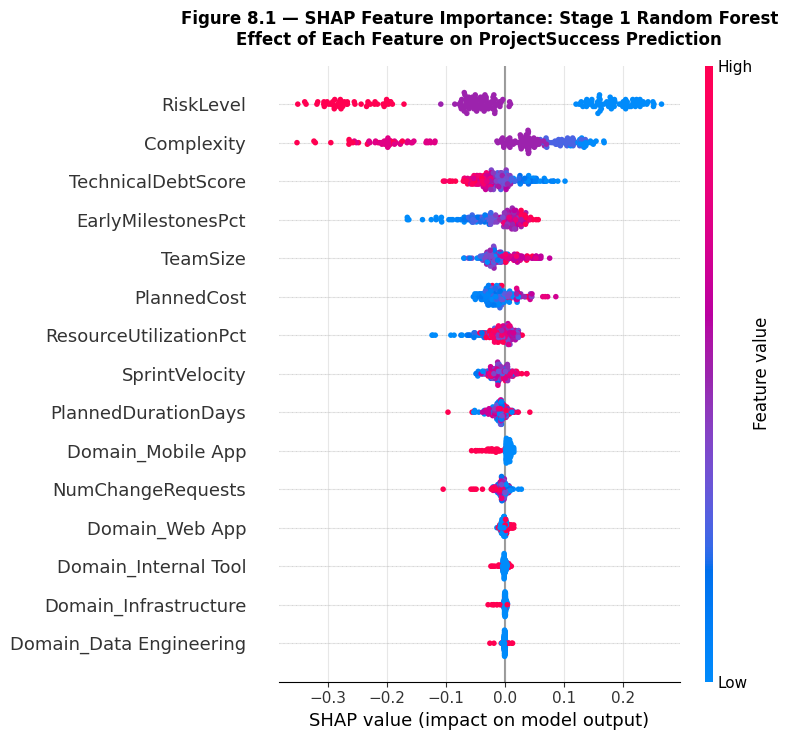

Figure 8.1 saved


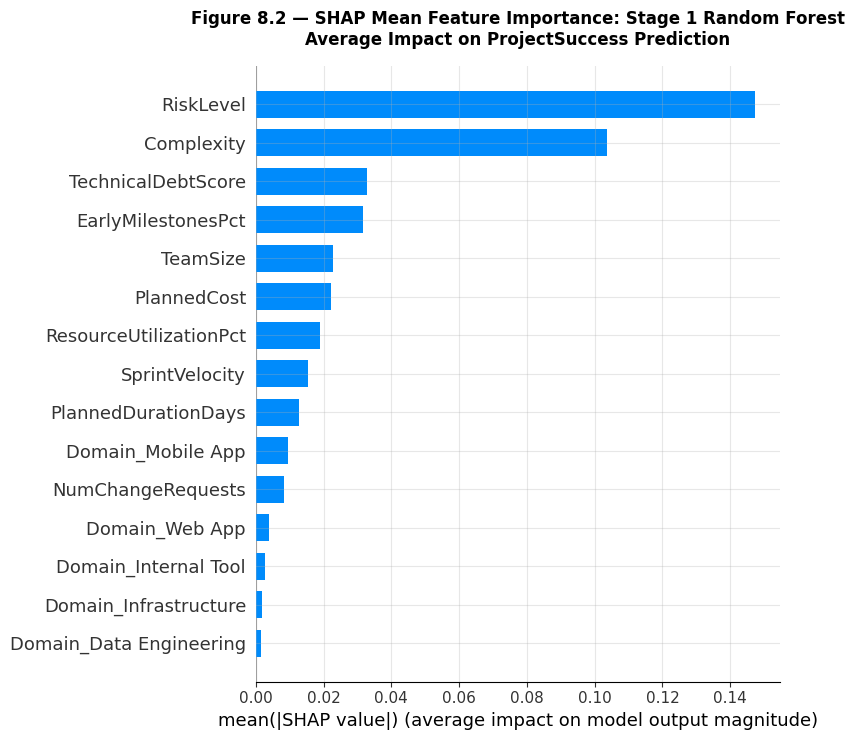

Figure 8.2 saved

Stage 1 Feature Importance Ranking (by Mean |SHAP|):
---------------------------------------------
   1. RiskLevel                      0.1474
   2. Complexity                     0.1037
   3. TechnicalDebtScore             0.0327
   4. EarlyMilestonesPct             0.0316
   5. TeamSize                       0.0229
   6. PlannedCost                    0.0221
   7. ResourceUtilizationPct         0.0189
   8. SprintVelocity                 0.0155
   9. PlannedDurationDays            0.0126
  10. Domain_Mobile App              0.0094
  11. NumChangeRequests              0.0082
  12. Domain_Web App                 0.0038
  13. Domain_Internal Tool           0.0026
  14. Domain_Infrastructure          0.0017
  15. Domain_Data Engineering        0.0016


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SHAP FEATURE IMPORTANCE ANALYSIS — STAGE 1")
print("Model: Random Forest (Best Stage 1 Model)")
print("Target: ProjectSuccess (Binary Classification)")
print("=" * 60)
print()

feature_names_s1 = X_test_s1_scaled.columns.tolist()

s1_explainer = shap.TreeExplainer(best_rf_b)
s1_shap_raw = s1_explainer.shap_values(X_test_s1_scaled)

# shape is (200, 15, 2) — extract class 1 (Success)
shap_success = s1_shap_raw[:, :, 1]
print(f"SHAP values shape for Success class: {shap_success.shape}")
print()

# Plot 1 — dot plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_success,
    X_test_s1_scaled,
    feature_names=feature_names_s1,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title(
    "Figure 8.1 — SHAP Feature Importance: Stage 1 Random Forest\n"
    "Effect of Each Feature on ProjectSuccess Prediction",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig8_1_shap_s1_dot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 8.1 saved")

# Plot 2 — bar plot
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_success,
    X_test_s1_scaled,
    feature_names=feature_names_s1,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title(
    "Figure 8.2 — SHAP Mean Feature Importance: Stage 1 Random Forest\n"
    "Average Impact on ProjectSuccess Prediction",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig8_2_shap_s1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 8.2 saved")
print()

# Ranked importance table
s1_mean_shap = np.abs(shap_success).mean(axis=0)
s1_importance = pd.Series(
    s1_mean_shap, index=feature_names_s1
).sort_values(ascending=False)

print("Stage 1 Feature Importance Ranking (by Mean |SHAP|):")
print("-" * 45)
for rank, (feat, val) in enumerate(s1_importance.items(), 1):
    print(f"  {rank:2}. {feat:<30} {val:.4f}")

In [ ]:
#STAGE 2 - COST OVERRUN BUCKET CLASSIFICATION
print("=" * 60)
print("STAGE 2 - COST OVERRUN BUCKET CLASSIFICATION")
print("Target Variable: CostOverrunBucket (Multi-Class)")
print("=" * 60)
print()

# Reset results dictionaries for Stage 2
stage2_results = {}
stage2_models = {}

# Reminder of class distribution
print("Class distribution in training set:")
for cls in sorted(y2_train.unique()):
    label = bucket_encoder.inverse_transform([cls])[0]
    count = int((y2_train == cls).sum())
    pct = (y2_train == cls).mean() * 100
    print(f"  Class {cls} ({label}): {count} samples ({pct:.1f}%)")
print()
print("Note: This is a severely imbalanced multi-class problem")
print("class_weight='balanced' will be applied to all models")

STAGE 2 - COST OVERRUN BUCKET CLASSIFICATION
Target Variable: CostOverrunBucket (Multi-Class)

Class distribution in training set:
  Class 0 (Acceptable): 520 samples (65.0%)
  Class 1 (Significant): 280 samples (35.0%)

Note: This is a severely imbalanced multi-class problem
class_weight='balanced' will be applied to all models


In [ ]:
#MULTI-CLASS EVALUATION
def evaluate_model_multiclass(model_name, y_true, y_pred,
                               class_labels=None):
    """
    Evaluates a multi-class classification model
    """
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred,
                                average='weighted',
                                zero_division=0)
    recall    = recall_score(y_true, y_pred,
                             average='weighted',
                             zero_division=0)
    f1_weighted = f1_score(y_true, y_pred,
                           average='weighted',
                           zero_division=0)
    f1_macro  = f1_score(y_true, y_pred,
                         average='macro',
                         zero_division=0)

    print(f"\n{'-'*50}")
    print(f"{model_name} - Stage 2 Results")
    print(f"{'-'*50}")
    print(f"  Accuracy:          {accuracy*100:.2f}%")
    print(f"  Precision:         {precision*100:.2f}%")
    print(f"  Recall:            {recall*100:.2f}%")
    print(f"  F1 (Weighted):     {f1_weighted*100:.2f}%")
    print(f"  F1 (Macro):        {f1_macro*100:.2f}%")
    print()
    print("  Full Classification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=class_labels if class_labels else None,
        zero_division=0
    ))

    return {
        'Accuracy':     round(accuracy * 100, 2),
        'Precision':    round(precision * 100, 2),
        'Recall':       round(recall * 100, 2),
        'F1 Weighted':  round(f1_weighted * 100, 2),
        'F1 Macro':     round(f1_macro * 100, 2)
    }

# Get class labels for reporting
class_labels_s2 = [
    bucket_encoder.inverse_transform([i])[0]
    for i in sorted(y2_train.unique())
]
print("Class labels for Stage 2:")
print(class_labels_s2)

Class labels for Stage 2:
['Acceptable', 'Significant']


In [ ]:
def safe_classification_report(y_true, y_pred, class_labels):
    """
    Generates classification report safely
    even when some classes are missing from test set
    """
    # Get only classes that actually appear
    present_classes = sorted(set(list(y_true) + list(y_pred)))
    present_labels  = [class_labels[i] for i in present_classes]

    return classification_report(
        y_true, y_pred,
        labels=present_classes,
        target_names=present_labels,
        zero_division=0
    )

Training Stage 2 Model 1: SVM

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best SVM parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1: 63.63%

SVM Stage 2 Results:
  Accuracy:      65.00%
  Precision:     66.53%
  Recall:        65.00%
  F1 Weighted:   65.53%
  F1 Macro:      62.86%

              precision    recall  f1-score   support

  Acceptable       0.75      0.68      0.72       130
 Significant       0.50      0.59      0.54        70

    accuracy                           0.65       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.67      0.65      0.66       200



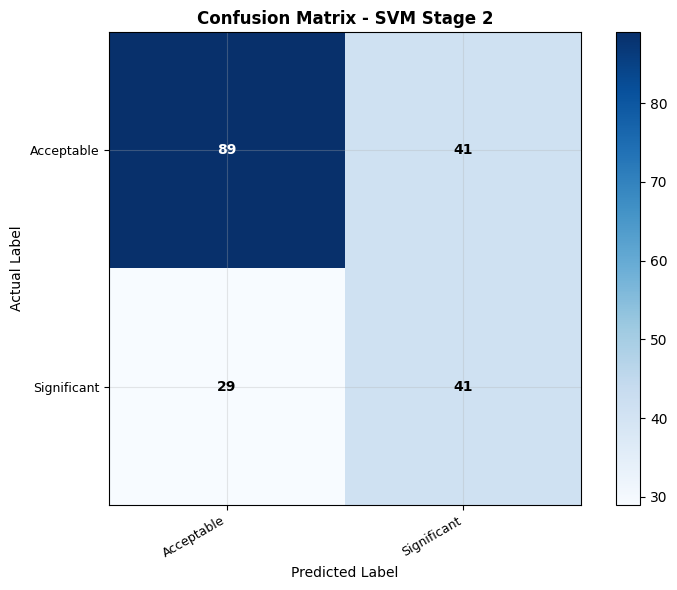

In [ ]:

# STAGE 2 - SVM WITH DIRECT INLINE PLOTS

print("Training Stage 2 Model 1: SVM")
print()

svm_param_grid_s2 = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

svm_grid_s2 = GridSearchCV(
    SVC(
        probability=True,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        decision_function_shape='ovr'
    ),
    svm_param_grid_s2,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_s2.fit(X_train_s2_scaled, y2_train)

print(f"\nBest SVM parameters: {svm_grid_s2.best_params_}")
print(f"Best CV F1: {svm_grid_s2.best_score_*100:.2f}%")

best_svm_s2 = svm_grid_s2.best_estimator_
y_pred_svm_s2 = best_svm_s2.predict(X_test_s2_scaled)

# Evaluate
accuracy  = accuracy_score(y2_test, y_pred_svm_s2)
f1_w      = f1_score(y2_test, y_pred_svm_s2,
                     average='weighted', zero_division=0)
f1_m      = f1_score(y2_test, y_pred_svm_s2,
                     average='macro', zero_division=0)
precision = precision_score(y2_test, y_pred_svm_s2,
                            average='weighted', zero_division=0)
recall    = recall_score(y2_test, y_pred_svm_s2,
                         average='weighted', zero_division=0)

print(f"\nSVM Stage 2 Results:")
print(f"  Accuracy:      {accuracy*100:.2f}%")
print(f"  Precision:     {precision*100:.2f}%")
print(f"  Recall:        {recall*100:.2f}%")
print(f"  F1 Weighted:   {f1_w*100:.2f}%")
print(f"  F1 Macro:      {f1_m*100:.2f}%")
print()
print(safe_classification_report(y2_test, y_pred_svm_s2, class_labels_s2))

stage2_results['SVM'] = {
    'Accuracy':    round(accuracy_score(y2_test, y_pred_svm_s2)*100, 2),
    'Precision':   round(precision_score(y2_test, y_pred_svm_s2, average='weighted', zero_division=0)*100, 2),
    'Recall':      round(recall_score(y2_test, y_pred_svm_s2, average='weighted', zero_division=0)*100, 2),
    'F1 Weighted': round(f1_score(y2_test, y_pred_svm_s2, average='weighted', zero_division=0)*100, 2),
    'F1 Macro':    round(f1_score(y2_test, y_pred_svm_s2, average='macro', zero_division=0)*100, 2)
}
stage2_models['SVM'] = best_svm_s2

# Confusion matrix
unique_classes_svm = sorted(set(list(y2_test) + list(y_pred_svm_s2)))
labels_svm = [class_labels_s2[i] for i in unique_classes_svm]
cm_svm = confusion_matrix(y2_test, y_pred_svm_s2, labels=unique_classes_svm)
n = len(unique_classes_svm)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_svm, cmap='Blues')
fig.colorbar(im, ax=ax)
thresh = cm_svm.max() / 2.0
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm_svm[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cm_svm[i, j] > thresh else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_svm, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_svm, fontsize=9)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix - SVM Stage 2', fontweight='bold')
fig.tight_layout()
fig.savefig('fig7_1_svm_s2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Training Stage 2 Model 2: Logistic Regression

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best LR parameters: {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 61.26%

Logistic Regression Stage 2 Results:
  Accuracy:      64.00%
  Precision:     67.07%
  Recall:        64.00%
  F1 Weighted:   64.78%
  F1 Macro:      62.65%

              precision    recall  f1-score   support

  Acceptable       0.77      0.64      0.70       130
 Significant       0.49      0.64      0.56        70

    accuracy                           0.64       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.67      0.64      0.65       200



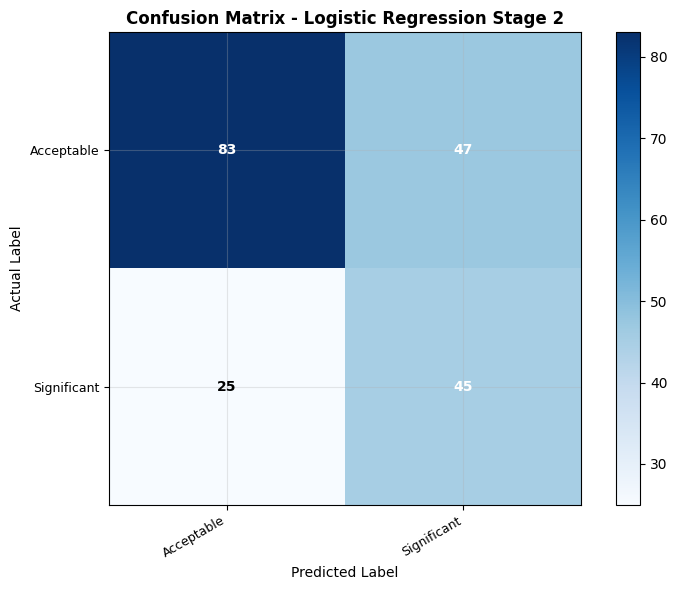

In [ ]:

# LOGISTIC REGRESSION STAGE 2


print("Training Stage 2 Model 2: Logistic Regression")
print()

lr_param_grid_s2 = {
    'C':        [0.01, 0.1, 1, 10],
    'solver':   ['lbfgs', 'saga'],
    'penalty':  ['l2'],
    'max_iter': [500, 1000]
}

lr_grid_s2 = GridSearchCV(
    LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        multi_class='multinomial'
    ),
    lr_param_grid_s2,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lr_grid_s2.fit(X_train_s2_scaled, y2_train)

print(f"\nBest LR parameters: {lr_grid_s2.best_params_}")
print(f"Best CV F1: {lr_grid_s2.best_score_*100:.2f}%")

best_lr_s2     = lr_grid_s2.best_estimator_
y_pred_lr_s2   = best_lr_s2.predict(X_test_s2_scaled)

accuracy  = accuracy_score(y2_test, y_pred_lr_s2)
f1_w      = f1_score(y2_test, y_pred_lr_s2, average='weighted', zero_division=0)
f1_m      = f1_score(y2_test, y_pred_lr_s2, average='macro', zero_division=0)
precision = precision_score(y2_test, y_pred_lr_s2, average='weighted', zero_division=0)
recall    = recall_score(y2_test, y_pred_lr_s2, average='weighted', zero_division=0)

print(f"\nLogistic Regression Stage 2 Results:")
print(f"  Accuracy:      {accuracy*100:.2f}%")
print(f"  Precision:     {precision*100:.2f}%")
print(f"  Recall:        {recall*100:.2f}%")
print(f"  F1 Weighted:   {f1_w*100:.2f}%")
print(f"  F1 Macro:      {f1_m*100:.2f}%")
print()
print(safe_classification_report(y2_test, y_pred_lr_s2, class_labels_s2))

stage2_results['Logistic Regression'] = {
    'Accuracy':    round(accuracy*100, 2),
    'Precision':   round(precision*100, 2),
    'Recall':      round(recall*100, 2),
    'F1 Weighted': round(f1_w*100, 2),
    'F1 Macro':    round(f1_m*100, 2)
}
stage2_models['Logistic Regression'] = best_lr_s2

unique_classes_lr = sorted(set(list(y2_test) + list(y_pred_lr_s2)))
labels_lr = [class_labels_s2[i] for i in unique_classes_lr]
cm_lr = confusion_matrix(y2_test, y_pred_lr_s2, labels=unique_classes_lr)
n = len(unique_classes_lr)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_lr, cmap='Blues')
fig.colorbar(im, ax=ax)
thresh = cm_lr.max() / 2.0
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm_lr[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cm_lr[i, j] > thresh else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_lr, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_lr, fontsize=9)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix - Logistic Regression Stage 2',
             fontweight='bold')
fig.tight_layout()
fig.savefig('fig7_2_lr_s2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Training Stage 2 Model 3: Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 65.78%

Random Forest Stage 2 Results:
  Accuracy:      67.00%
  Precision:     65.14%
  Recall:        67.00%
  F1 Weighted:   65.21%
  F1 Macro:      60.33%

              precision    recall  f1-score   support

  Acceptable       0.71      0.83      0.77       130
 Significant       0.54      0.37      0.44        70

    accuracy                           0.67       200
   macro avg       0.63      0.60      0.60       200
weighted avg       0.65      0.67      0.65       200



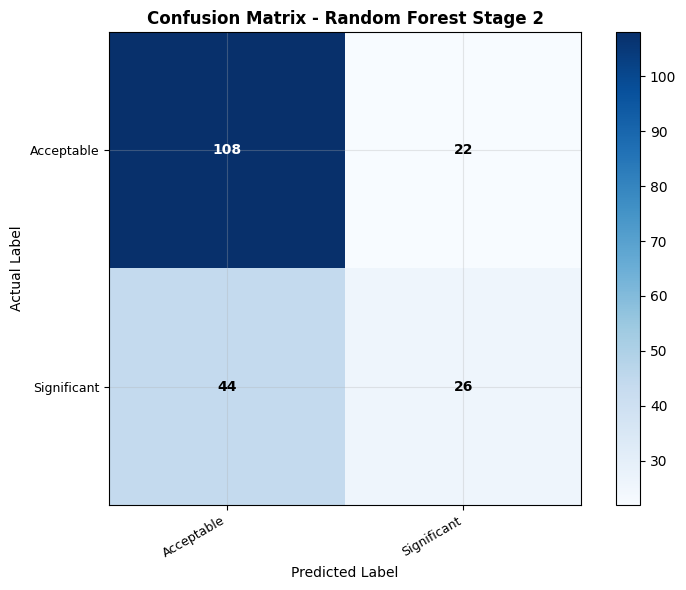

In [ ]:

# RANDOM FOREST STAGE 2


print("Training Stage 2 Model 3: Random Forest")
print()

rf_param_grid_s2 = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid_s2 = GridSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    rf_param_grid_s2,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid_s2.fit(X_train_s2_scaled, y2_train)

print(f"\nBest RF parameters: {rf_grid_s2.best_params_}")
print(f"Best CV F1: {rf_grid_s2.best_score_*100:.2f}%")

best_rf_s2    = rf_grid_s2.best_estimator_
y_pred_rf_s2  = best_rf_s2.predict(X_test_s2_scaled)

accuracy  = accuracy_score(y2_test, y_pred_rf_s2)
f1_w      = f1_score(y2_test, y_pred_rf_s2, average='weighted', zero_division=0)
f1_m      = f1_score(y2_test, y_pred_rf_s2, average='macro', zero_division=0)
precision = precision_score(y2_test, y_pred_rf_s2, average='weighted', zero_division=0)
recall    = recall_score(y2_test, y_pred_rf_s2, average='weighted', zero_division=0)

print(f"\nRandom Forest Stage 2 Results:")
print(f"  Accuracy:      {accuracy*100:.2f}%")
print(f"  Precision:     {precision*100:.2f}%")
print(f"  Recall:        {recall*100:.2f}%")
print(f"  F1 Weighted:   {f1_w*100:.2f}%")
print(f"  F1 Macro:      {f1_m*100:.2f}%")
print()
print(safe_classification_report(y2_test, y_pred_rf_s2, class_labels_s2))

stage2_results['Random Forest'] = {
    'Accuracy':    round(accuracy*100, 2),
    'Precision':   round(precision*100, 2),
    'Recall':      round(recall*100, 2),
    'F1 Weighted': round(f1_w*100, 2),
    'F1 Macro':    round(f1_m*100, 2)
}
stage2_models['Random Forest'] = best_rf_s2

unique_classes_rf = sorted(set(list(y2_test) + list(y_pred_rf_s2)))
labels_rf = [class_labels_s2[i] for i in unique_classes_rf]
cm_rf = confusion_matrix(y2_test, y_pred_rf_s2, labels=unique_classes_rf)
n = len(unique_classes_rf)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_rf, cmap='Blues')
fig.colorbar(im, ax=ax)
thresh = cm_rf.max() / 2.0
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm_rf[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cm_rf[i, j] > thresh else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_rf, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_rf, fontsize=9)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix - Random Forest Stage 2',
             fontweight='bold')
fig.tight_layout()
fig.savefig('fig7_3_rf_s2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Training Stage 2 Model 4: CatBoost

  {'iterations': 100, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1} -> CV F1: 62.76%
  {'iterations': 100, 'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3} -> CV F1: 64.24%
  {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1} -> CV F1: 63.00%
  {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3} -> CV F1: 63.98%

Best CatBoost params: {'iterations': 100, 'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3}
Best CV F1: 64.24%

CatBoost Stage 2 Results:
  Accuracy:      66.00%
  Precision:     65.78%
  Recall:        66.00%
  F1 Weighted:   65.88%
  F1 Macro:      62.39%

              precision    recall  f1-score   support

  Acceptable       0.73      0.75      0.74       130
 Significant       0.51      0.50      0.51        70

    accuracy                           0.66       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.66      0.66      0.66       200



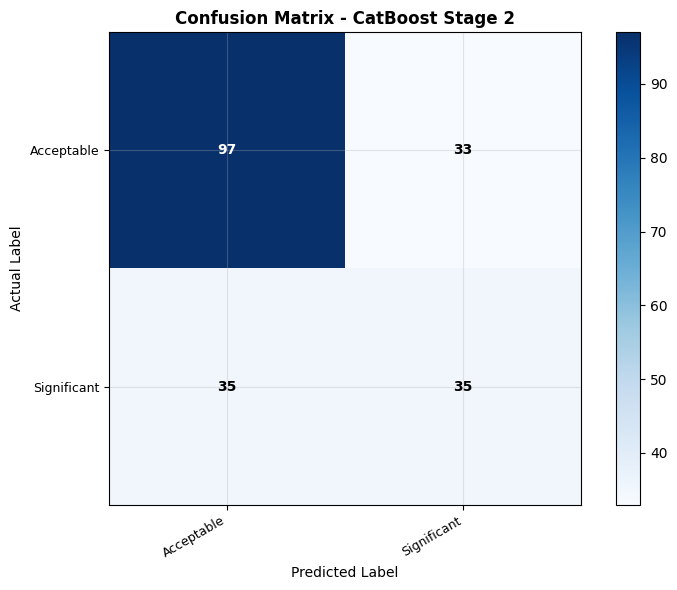

In [ ]:

# CATBOOST STAGE 2 - CORRECTED


print("Training Stage 2 Model 4: CatBoost")
print()

catboost_params_s2 = [
    {'iterations': 100, 'depth': 4, 'learning_rate': 0.1,  'l2_leaf_reg': 1},
    {'iterations': 100, 'depth': 6, 'learning_rate': 0.1,  'l2_leaf_reg': 3},
    {'iterations': 200, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1},
    {'iterations': 200, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3},
]

best_cb_score_s2 = 0
best_cb_params_s2 = None
best_cb_model_s2  = None

for params in catboost_params_s2:
    cb_model_s2 = CatBoostClassifier(
        iterations=params['iterations'],
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        l2_leaf_reg=params['l2_leaf_reg'],
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0,
        loss_function='MultiClass'
    )
    scores = cross_val_score(
        cb_model_s2, X_train_s2_scaled, y2_train,
        cv=5, scoring='f1_weighted', n_jobs=-1
    )
    mean_score = scores.mean()
    print(f"  {params} -> CV F1: {mean_score*100:.2f}%")

    if mean_score > best_cb_score_s2:
        best_cb_score_s2  = mean_score
        best_cb_params_s2 = params
        best_cb_model_s2  = cb_model_s2

print(f"\nBest CatBoost params: {best_cb_params_s2}")
print(f"Best CV F1: {best_cb_score_s2*100:.2f}%")

best_cb_model_s2.fit(X_train_s2_scaled, y2_train, verbose=0)
y_pred_cb_s2 = best_cb_model_s2.predict(X_test_s2_scaled)

if len(np.array(y_pred_cb_s2).shape) > 1:
    y_pred_cb_s2 = np.array(y_pred_cb_s2).flatten()
y_pred_cb_s2 = np.array(y_pred_cb_s2, dtype=int)

accuracy  = accuracy_score(y2_test, y_pred_cb_s2)
f1_w      = f1_score(y2_test, y_pred_cb_s2, average='weighted', zero_division=0)
f1_m      = f1_score(y2_test, y_pred_cb_s2, average='macro', zero_division=0)
precision = precision_score(y2_test, y_pred_cb_s2, average='weighted', zero_division=0)
recall    = recall_score(y2_test, y_pred_cb_s2, average='weighted', zero_division=0)

print(f"\nCatBoost Stage 2 Results:")
print(f"  Accuracy:      {accuracy*100:.2f}%")
print(f"  Precision:     {precision*100:.2f}%")
print(f"  Recall:        {recall*100:.2f}%")
print(f"  F1 Weighted:   {f1_w*100:.2f}%")
print(f"  F1 Macro:      {f1_m*100:.2f}%")
print()
print(safe_classification_report(y2_test, y_pred_cb_s2, class_labels_s2))

stage2_results['CatBoost'] = {
    'Accuracy':    round(accuracy*100, 2),
    'Precision':   round(precision*100, 2),
    'Recall':      round(recall*100, 2),
    'F1 Weighted': round(f1_w*100, 2),
    'F1 Macro':    round(f1_m*100, 2)
}
stage2_models['CatBoost'] = best_cb_model_s2

unique_classes_cb = sorted(set(list(y2_test) + list(y_pred_cb_s2)))
labels_cb = [class_labels_s2[i] for i in unique_classes_cb]
cm_cb = confusion_matrix(y2_test, y_pred_cb_s2, labels=unique_classes_cb)
n = len(unique_classes_cb)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_cb, cmap='Blues')
fig.colorbar(im, ax=ax)
thresh = cm_cb.max() / 2.0
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm_cb[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cm_cb[i, j] > thresh else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_cb, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_cb, fontsize=9)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix - CatBoost Stage 2', fontweight='bold')
fig.tight_layout()
fig.savefig('fig7_4_catboost_s2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Building Stage 2 Stacking Ensemble...

Training stacking ensemble - may take a few minutes...

Stacking Ensemble Stage 2 Results:
  Accuracy:      62.00%
  Precision:     65.44%
  Recall:        62.00%
  F1 Weighted:   62.85%
  F1 Macro:      60.73%

              precision    recall  f1-score   support

  Acceptable       0.75      0.62      0.68       130
 Significant       0.47      0.63      0.54        70

    accuracy                           0.62       200
   macro avg       0.61      0.62      0.61       200
weighted avg       0.65      0.62      0.63       200



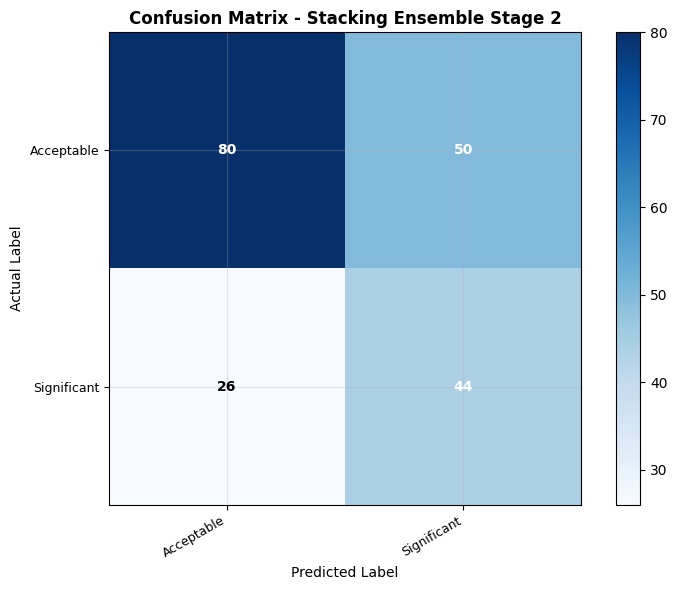

In [ ]:

# STACKING ENSEMBLE STAGE 2


print("Building Stage 2 Stacking Ensemble...")
print()

base_learners_s2 = [
    ('svm', SVC(
        C=svm_grid_s2.best_params_['C'],
        kernel=svm_grid_s2.best_params_['kernel'],
        gamma=svm_grid_s2.best_params_['gamma'],
        probability=True,
        class_weight='balanced',
        decision_function_shape='ovr',
        random_state=RANDOM_STATE
    )),
    ('lr', LogisticRegression(
        C=lr_grid_s2.best_params_['C'],
        solver=lr_grid_s2.best_params_['solver'],
        penalty='l2',
        max_iter=lr_grid_s2.best_params_['max_iter'],
        class_weight='balanced',
        multi_class='multinomial',
        random_state=RANDOM_STATE
    )),
    ('rf', RandomForestClassifier(
        n_estimators=rf_grid_s2.best_params_['n_estimators'],
        max_depth=rf_grid_s2.best_params_['max_depth'],
        min_samples_split=rf_grid_s2.best_params_['min_samples_split'],
        min_samples_leaf=rf_grid_s2.best_params_['min_samples_leaf'],
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('catboost', CatBoostClassifier(
        iterations=best_cb_params_s2['iterations'],
        depth=best_cb_params_s2['depth'],
        learning_rate=best_cb_params_s2['learning_rate'],
        l2_leaf_reg=best_cb_params_s2['l2_leaf_reg'],
        auto_class_weights='Balanced',
        loss_function='MultiClass',
        random_state=RANDOM_STATE,
        verbose=0
    ))
]

meta_learner_s2 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced',
    multi_class='multinomial'
)

stacking_clf_s2 = StackingClassifier(
    estimators=base_learners_s2,
    final_estimator=meta_learner_s2,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

print("Training stacking ensemble - may take a few minutes...")
stacking_clf_s2.fit(X_train_s2_scaled, y2_train)

y_pred_stack_s2 = stacking_clf_s2.predict(X_test_s2_scaled)

accuracy  = accuracy_score(y2_test, y_pred_stack_s2)
f1_w      = f1_score(y2_test, y_pred_stack_s2, average='weighted', zero_division=0)
f1_m      = f1_score(y2_test, y_pred_stack_s2, average='macro', zero_division=0)
precision = precision_score(y2_test, y_pred_stack_s2, average='weighted', zero_division=0)
recall    = recall_score(y2_test, y_pred_stack_s2, average='weighted', zero_division=0)

print(f"\nStacking Ensemble Stage 2 Results:")
print(f"  Accuracy:      {accuracy*100:.2f}%")
print(f"  Precision:     {precision*100:.2f}%")
print(f"  Recall:        {recall*100:.2f}%")
print(f"  F1 Weighted:   {f1_w*100:.2f}%")
print(f"  F1 Macro:      {f1_m*100:.2f}%")
print()
print(safe_classification_report(
    y2_test, y_pred_stack_s2, class_labels_s2
))

stage2_results['Stacking Ensemble'] = {
    'Accuracy':    round(accuracy*100, 2),
    'Precision':   round(precision*100, 2),
    'Recall':      round(recall*100, 2),
    'F1 Weighted': round(f1_w*100, 2),
    'F1 Macro':    round(f1_m*100, 2)
}
stage2_models['Stacking Ensemble'] = stacking_clf_s2

unique_classes_st = sorted(set(
    list(y2_test) + list(y_pred_stack_s2)
))
labels_st = [class_labels_s2[i] for i in unique_classes_st]
cm_st = confusion_matrix(y2_test, y_pred_stack_s2,
                         labels=unique_classes_st)
n = len(unique_classes_st)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_st, cmap='Blues')
fig.colorbar(im, ax=ax)
thresh = cm_st.max() / 2.0
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm_st[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cm_st[i, j] > thresh else 'black')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_st, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_st, fontsize=9)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix - Stacking Ensemble Stage 2',
             fontweight='bold')
fig.tight_layout()
fig.savefig('fig7_5_stacking_s2_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()


STAGE 2 COMPLETE COMPARISON

All Stage 2 Results (sorted by F1 Weighted):
                     Accuracy  Precision  Recall  F1 Weighted  F1 Macro
CatBoost                 66.0      65.78    66.0        65.88     62.39
SVM                      65.0      66.53    65.0        65.53     62.86
Random Forest            67.0      65.14    67.0        65.21     60.33
Logistic Regression      64.0      67.07    64.0        64.78     62.65
Stacking Ensemble        62.0      65.44    62.0        62.85     60.73

Best Individual Model: CatBoost (65.88%)
Stacking Ensemble F1:  62.85%

Best individual outperformed stacking by 3.03%


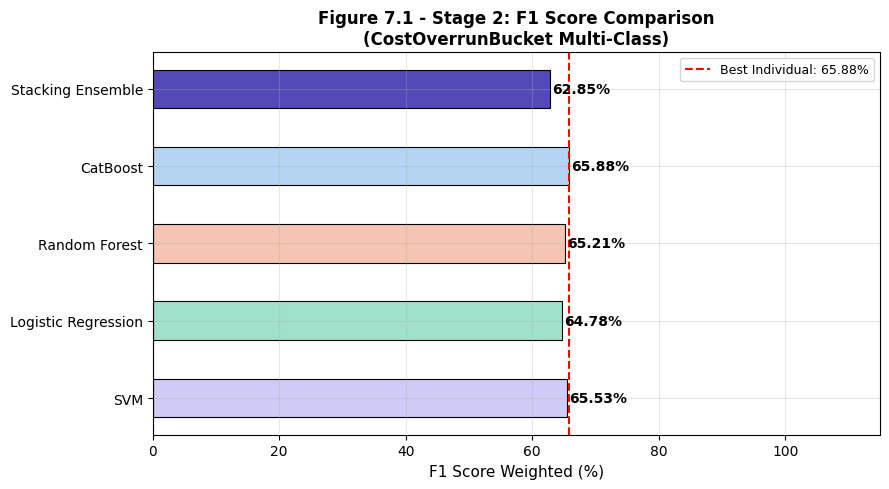

In [ ]:

# STAGE 2 COMPARISON


print("=" * 60)
print("STAGE 2 COMPLETE COMPARISON")
print("=" * 60)
print()

results_df_s2 = pd.DataFrame(stage2_results).T
results_df_s2 = results_df_s2.sort_values('F1 Weighted', ascending=False)

print("All Stage 2 Results (sorted by F1 Weighted):")
print(results_df_s2.to_string())
print()

best_ind_s2    = results_df_s2.drop('Stacking Ensemble').index[0]
best_ind_s2_f1 = results_df_s2.loc[best_ind_s2, 'F1 Weighted']
stack_s2_f1    = results_df_s2.loc['Stacking Ensemble', 'F1 Weighted']

print(f"Best Individual Model: {best_ind_s2} ({best_ind_s2_f1:.2f}%)")
print(f"Stacking Ensemble F1:  {stack_s2_f1:.2f}%")
print()

if stack_s2_f1 > best_ind_s2_f1:
    print(f"Stacking IMPROVED by {stack_s2_f1 - best_ind_s2_f1:.2f}%")
else:
    print(f"Best individual outperformed stacking by "
          f"{best_ind_s2_f1 - stack_s2_f1:.2f}%")

all_models_s2 = list(stage2_results.keys())
all_colors_s2 = ['#CECBF6', '#9FE1CB', '#F5C4B3', '#B5D4F4', '#534AB7']
f1_scores_s2  = [stage2_results[m]['F1 Weighted'] for m in all_models_s2]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    all_models_s2, f1_scores_s2,
    color=all_colors_s2,
    edgecolor='black', linewidth=0.8, height=0.5
)
ax.axvline(
    x=best_ind_s2_f1, color='red',
    linestyle='--', linewidth=1.5,
    label=f'Best Individual: {best_ind_s2_f1:.2f}%'
)
for bar, score in zip(bars, f1_scores_s2):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{score:.2f}%',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('F1 Score Weighted (%)', fontsize=11)
ax.set_title('Figure 7.1 - Stage 2: F1 Score Comparison\n'
             '(CostOverrunBucket Multi-Class)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 115)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig('fig7_6_stage2_f1_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print()


SHAP FEATURE IMPORTANCE ANALYSIS — STAGE 2
Model: CatBoost (Best Stage 2 Model by F1 Weighted)
Target: CostOverrunBucket (Acceptable vs Significant)

S2 SHAP raw type: <class 'numpy.ndarray'>
3D array shape: (200, 15, 2)
SHAP values shape for Significant class: (200, 15)



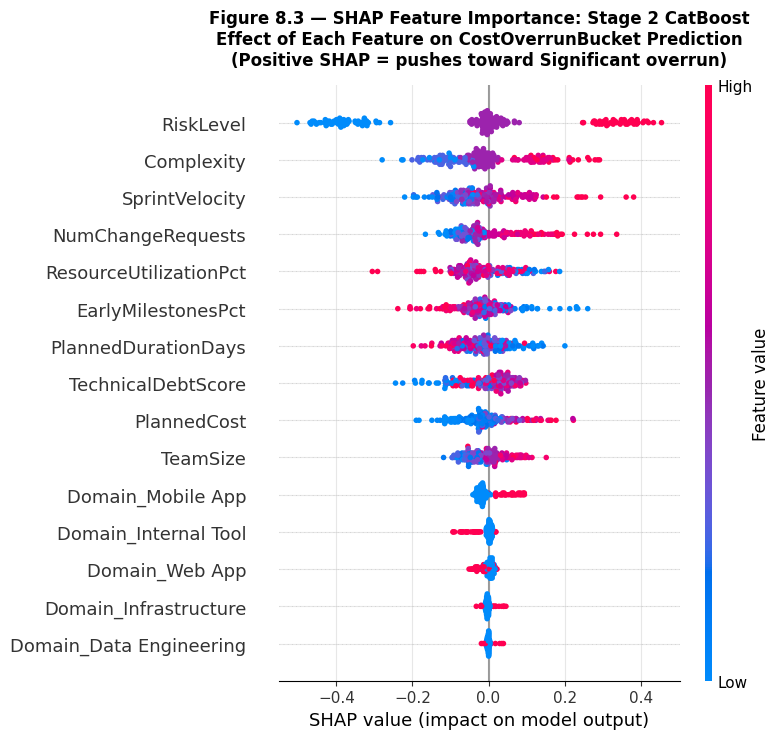

Figure 8.3 saved


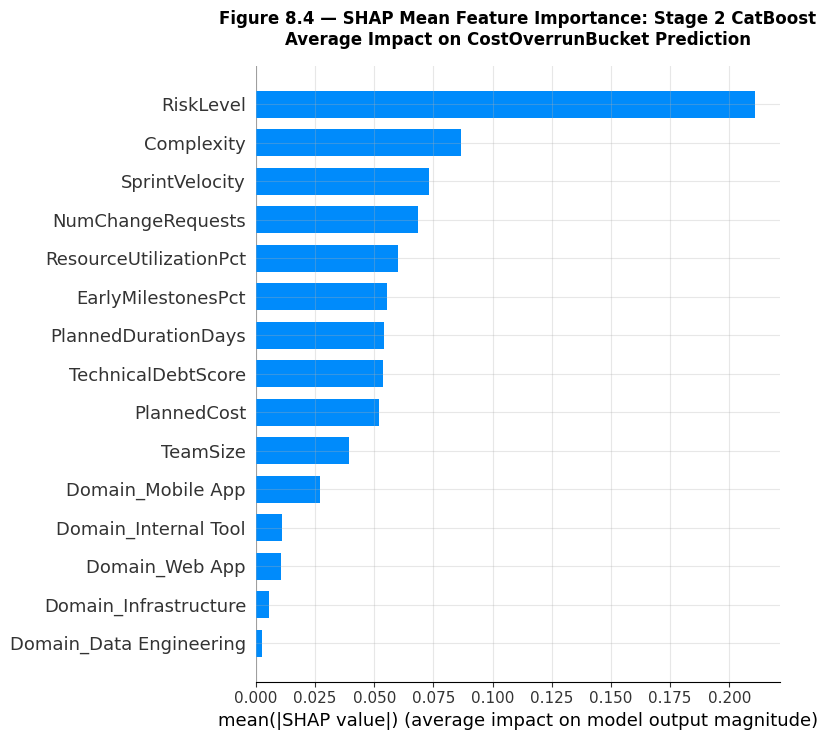

Figure 8.4 saved

Stage 2 Feature Importance Ranking (by Mean |SHAP|):
---------------------------------------------
   1. RiskLevel                      0.2109
   2. Complexity                     0.0865
   3. SprintVelocity                 0.0730
   4. NumChangeRequests              0.0686
   5. ResourceUtilizationPct         0.0601
   6. EarlyMilestonesPct             0.0553
   7. PlannedDurationDays            0.0540
   8. TechnicalDebtScore             0.0535
   9. PlannedCost                    0.0522
  10. TeamSize                       0.0394
  11. Domain_Mobile App              0.0271
  12. Domain_Internal Tool           0.0110
  13. Domain_Web App                 0.0106
  14. Domain_Infrastructure          0.0054
  15. Domain_Data Engineering        0.0027


CROSS-STAGE SHAP COMPARISON
Stage 1 (ProjectSuccess) vs Stage 2 (CostOverrunBucket)

Feature                         S1 Rank  S2 Rank    Shift
------------------------------------------------------------
  RiskLevel      

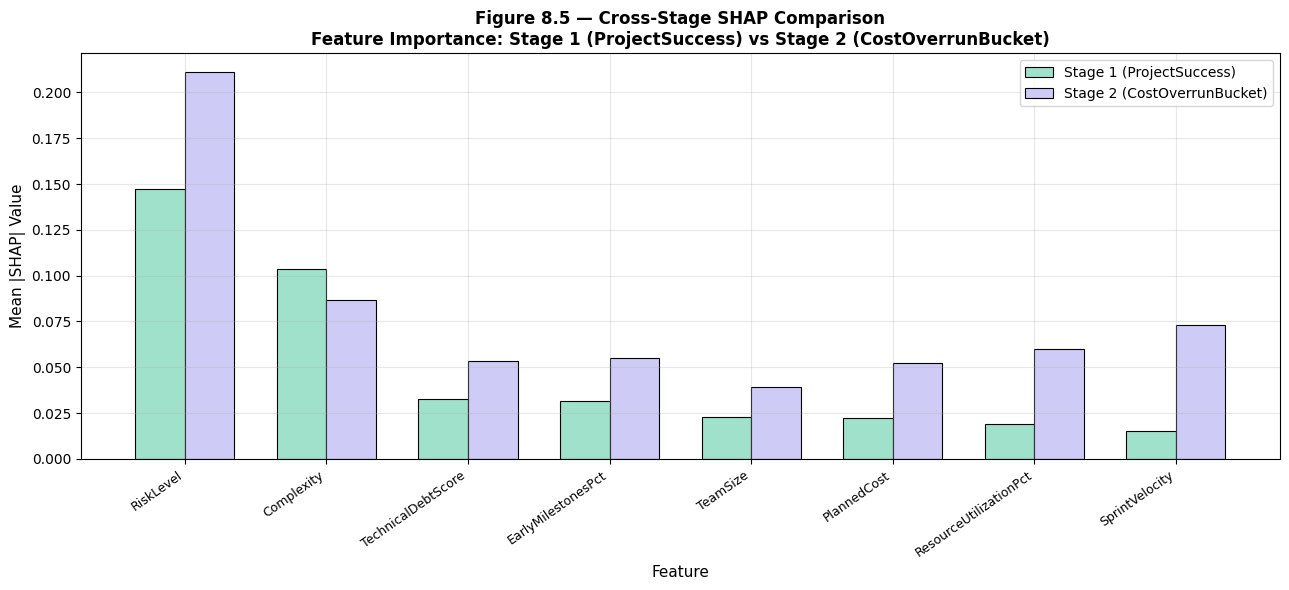

Figure 8.5 saved

KEY CROSS-STAGE FINDING

Top feature in Stage 1: RiskLevel
Top feature in Stage 2: RiskLevel

Same top feature across both stages.
This suggests one dominant risk driver across the framework.

All SHAP figures saved:
  fig8_1_shap_*.png
  fig8_2_shap_*.png
  fig8_3_shap_*.png
  fig8_4_shap_*.png
  fig8_5_shap_*.png


In [ ]:
# ================================================================
# SHAP SECTION 2 — STAGE 2 + CROSS-STAGE COMPARISON
# ================================================================

print("=" * 60)
print("SHAP FEATURE IMPORTANCE ANALYSIS — STAGE 2")
print("Model: CatBoost (Best Stage 2 Model by F1 Weighted)")
print("Target: CostOverrunBucket (Acceptable vs Significant)")
print("=" * 60)
print()

feature_names_s2 = X_test_s2_scaled.columns.tolist()

s2_explainer = shap.TreeExplainer(best_cb_model_s2)
s2_shap_raw = s2_explainer.shap_values(X_test_s2_scaled)

# handle all possible return shapes
print("S2 SHAP raw type:", type(s2_shap_raw))
if isinstance(s2_shap_raw, list):
    print("List length:", len(s2_shap_raw))
    print("Element 0 shape:", s2_shap_raw[0].shape)
    s2_shap = s2_shap_raw[1]  # class 1 = Significant
elif isinstance(s2_shap_raw, np.ndarray) and s2_shap_raw.ndim == 3:
    print("3D array shape:", s2_shap_raw.shape)
    s2_shap = s2_shap_raw[:, :, 1]  # class 1 = Significant
else:
    print("2D array shape:", s2_shap_raw.shape)
    s2_shap = s2_shap_raw

print(f"SHAP values shape for Significant class: {s2_shap.shape}")
print()

# Plot 3 — Stage 2 dot plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    s2_shap,
    X_test_s2_scaled,
    feature_names=feature_names_s2,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title(
    "Figure 8.3 — SHAP Feature Importance: Stage 2 CatBoost\n"
    "Effect of Each Feature on CostOverrunBucket Prediction\n"
    "(Positive SHAP = pushes toward Significant overrun)",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig8_3_shap_s2_dot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 8.3 saved")

# Plot 4 — Stage 2 bar plot
plt.figure(figsize=(9, 6))
shap.summary_plot(
    s2_shap,
    X_test_s2_scaled,
    feature_names=feature_names_s2,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title(
    "Figure 8.4 — SHAP Mean Feature Importance: Stage 2 CatBoost\n"
    "Average Impact on CostOverrunBucket Prediction",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig8_4_shap_s2_bar.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 8.4 saved")
print()

# Stage 2 ranking table
s2_mean_shap = np.abs(s2_shap).mean(axis=0)
s2_importance = pd.Series(
    s2_mean_shap, index=feature_names_s2
).sort_values(ascending=False)

print("Stage 2 Feature Importance Ranking (by Mean |SHAP|):")
print("-" * 45)
for rank, (feat, val) in enumerate(s2_importance.items(), 1):
    print(f"  {rank:2}. {feat:<30} {val:.4f}")
print()

# ================================================================
# CROSS-STAGE COMPARISON
# ================================================================
print()
print("=" * 60)
print("CROSS-STAGE SHAP COMPARISON")
print("Stage 1 (ProjectSuccess) vs Stage 2 (CostOverrunBucket)")
print("=" * 60)
print()

common_features = [f for f in feature_names_s1 if f in feature_names_s2]

s1_common = s1_importance[common_features]
s2_common = s2_importance[common_features]

s1_ranked = s1_common.sort_values(ascending=False)
s2_ranked = s2_common.sort_values(ascending=False)

print(f"{'Feature':<30} {'S1 Rank':>8} {'S2 Rank':>8} {'Shift':>8}")
print("-" * 60)
for feat in s1_ranked.index:
    r1 = list(s1_ranked.index).index(feat) + 1
    r2 = list(s2_ranked.index).index(feat) + 1
    shift = r1 - r2
    direction = f"+{shift}" if shift > 0 else str(shift)
    print(f"  {feat:<28} {r1:>8} {r2:>8} {direction:>8}")
print()

# Plot 5 — cross-stage comparison
top_features = s1_ranked.head(8).index.tolist()
top_in_both  = [f for f in top_features if f in s2_importance.index]

x     = np.arange(len(top_in_both))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2,
       [s1_importance[f] for f in top_in_both],
       width, label='Stage 1 (ProjectSuccess)',
       color='#9FE1CB', edgecolor='black', linewidth=0.8)
ax.bar(x + width/2,
       [s2_importance.get(f, 0) for f in top_in_both],
       width, label='Stage 2 (CostOverrunBucket)',
       color='#CECBF6', edgecolor='black', linewidth=0.8)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Mean |SHAP| Value', fontsize=11)
ax.set_title(
    "Figure 8.5 — Cross-Stage SHAP Comparison\n"
    "Feature Importance: Stage 1 (ProjectSuccess) vs "
    "Stage 2 (CostOverrunBucket)",
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(top_in_both, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_5_shap_cross_stage.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure 8.5 saved")
print()

print("=" * 60)
print("KEY CROSS-STAGE FINDING")
print("=" * 60)
print(f"\nTop feature in Stage 1: {s1_ranked.index[0]}")
print(f"Top feature in Stage 2: {s2_ranked.index[0]}")
print()
if s1_ranked.index[0] != s2_ranked.index[0]:
    print("Top features DIFFER between stages — key dissertation finding:")
    print(f"  '{s1_ranked.index[0]}' drives success/failure (Stage 1)")
    print(f"  '{s2_ranked.index[0]}' drives cost severity (Stage 2)")
    print()
    print("This means: the factors that determine WHETHER a project fails")
    print("are different from the factors that determine HOW BADLY it")
    print("overruns its budget. This cannot be observed in single-task models.")
else:
    print("Same top feature across both stages.")
    print("This suggests one dominant risk driver across the framework.")

print()
print("All SHAP figures saved:")
for i in range(1, 6):
    print(f"  fig8_{i}_shap_*.png")

In [ ]:
#STAGE 3 - BAYESIAN BETA REGRESSION
print("=" * 60)
print("SECTION 10: STAGE 3 - BAYESIAN BETA REGRESSION")
print("Target Variable: CostOverrunPct")
print("=" * 60)
print()


try:
    import pymc as pm
    import arviz as az
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")

except ImportError:
    print("Installing PyMC and ArviZ")
    import subprocess
    subprocess.run(["pip", "install", "pymc", "arviz", "-q"])
    import pymc as pm
    import arviz as az

SECTION 10: STAGE 3 - BAYESIAN BETA REGRESSION
Target Variable: CostOverrunPct

PyMC version: 5.28.5
ArviZ version: 0.22.0


In [ ]:
#PREPARE DATA FOR BAYESIAN REGRESSION
import numpy as np

# Checking current range
print(f"CostOverrunPct range:")
print(f"  Training - Min: {y3_train.min():.4f}, Max: {y3_train.max():.4f}")
print(f"  Testing  - Min: {y3_test.min():.4f},  Max: {y3_test.max():.4f}")
print()


epsilon = 0.001

# Convert to numpy arrays for PyMC
y3_train_beta = np.clip(np.array(y3_train,dtype=float),epsilon, 1 - epsilon)

y3_test_beta = np.clip(np.array(y3_test,dtype=float),epsilon, 1 - epsilon)

print(f"After clipping:")
print(f"  Train range: {y3_train_beta.min():.4f} to {y3_train_beta.max():.4f}")
print(f"  Test range:  {y3_test_beta.min():.4f} to {y3_test_beta.max():.4f}")
print()

# Convert feature matrices to numpy arrays
X_train_s3_np = np.array(X_train_s3_scaled, dtype=float)
X_test_s3_np  = np.array(X_test_s3_scaled, dtype=float)

print(f"Training features shape: {X_train_s3_np.shape}")
print(f"Testing features shape:  {X_test_s3_np.shape}")
print()

CostOverrunPct range:
  Training - Min: -0.3000, Max: 0.9031
  Testing  - Min: -0.3000,  Max: 0.8923

After clipping:
  Train range: 0.0010 to 0.9031
  Test range:  0.0010 to 0.8923

Training features shape: (800, 15)
Testing features shape:  (200, 15)



In [ ]:
#BASELINE COMPARISON - LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("STEP 10.2: Training Linear Regression Baseline")
print()

# Train simple linear regression
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_s3_np, y3_train_beta)

# Predict on test set
y_pred_lr_baseline = lr_baseline.predict(X_test_s3_np)

# Clip predictions to valid range
y_pred_lr_baseline = np.clip(y_pred_lr_baseline, epsilon, 1 - epsilon)

# Calculate metrics
mae_baseline = mean_absolute_error(y3_test_beta, y_pred_lr_baseline)
r2_baseline  = r2_score(y3_test_beta, y_pred_lr_baseline)

print(f"Linear Regression Baseline:")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  R2:  {r2_baseline:.4f}")
print()
print(f"Interpretation:")
print(f"  On average the baseline prediction is off by "
      f"{mae_baseline*100:.2f} percentage points")
print(f"  R2 of {r2_baseline:.4f} means the model explains "
      f"{r2_baseline*100:.1f}% of variance")

STEP 10.2: Training Linear Regression Baseline

Linear Regression Baseline:
  MAE: 0.1452
  R2:  0.1568

Interpretation:
  On average the baseline prediction is off by 14.52 percentage points
  R2 of 0.1568 means the model explains 15.7% of variance


In [ ]:
#BUILD BAYESIAN BETA REGRESSION MODEL
bayesian_features = [
    'TeamSize',
    'Complexity',
    'NumChangeRequests',
    'SprintVelocity',
    'TechnicalDebtScore',
    'EarlyMilestonesPct',
    'ResourceUtilizationPct'
]


feature_cols = list(X_train_s3_scaled.columns)
bayesian_indices = [
    feature_cols.index(f)
    for f in bayesian_features
    if f in feature_cols
]

print(f"Features used in Bayesian model ({len(bayesian_indices)}):")
for f in bayesian_features:
    if f in feature_cols:
        print(f"  - {f}")
print()

# Extract selected features
X_train_bayes = X_train_s3_np[:, bayesian_indices]
X_test_bayes  = X_test_s3_np[:, bayesian_indices]

n_features = X_train_bayes.shape[1]
n_train    = X_train_bayes.shape[0]

print(f"Training shape: {X_train_bayes.shape}")
print(f"Testing shape:  {X_test_bayes.shape}")
print()

Features used in Bayesian model (7):
  - TeamSize
  - Complexity
  - NumChangeRequests
  - SprintVelocity
  - TechnicalDebtScore
  - EarlyMilestonesPct
  - ResourceUtilizationPct

Training shape: (800, 7)
Testing shape:  (200, 7)



In [ ]:
#FIT THE BAYESIAN MODEL
import warnings
warnings.filterwarnings('ignore')

with pm.Model() as beta_model:

    # Data containers
    X_data = pm.Data('X', X_train_bayes)
    y_data = pm.Data('y', y3_train_beta)


    beta_0 = pm.Normal('beta_0', mu=0, sigma=0.5)

    # Feature coefficients: one for each feature
    beta = pm.Normal('beta', mu=0, sigma=0.5,
                     shape=n_features)

    # Precision parameter: must be positive
    phi = pm.HalfNormal('phi', sigma=1)

    # Linear combination

    mu = pm.Deterministic(
        'mu',
        pm.math.sigmoid(beta_0 + pm.math.dot(X_data, beta))
    )

    #  Beta distribution parameters

    alpha_param = pm.Deterministic('alpha_param', mu * phi)
    beta_param  = pm.Deterministic('beta_param', (1 - mu) * phi)


    # Beta distribution with parameters alpha and beta
    y_obs = pm.Beta('y_obs',
                    alpha=alpha_param,
                    beta=beta_param,
                    observed=y_data)


    trace = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42
    )

print()

Output()

In [ ]:
#CHECK MODEL QUALITY
summary = az.summary(trace, var_names=['beta_0', 'beta', 'phi'])
print("Model Summary (R-hat should be close to 1.0):")
print(summary[['mean', 'sd', 'r_hat', 'ess_bulk']].to_string())
print()

# Check if any R-hat values are concerning
r_hat_values = summary['r_hat'].values
max_r_hat = r_hat_values.max()

if max_r_hat < 1.1:
    print(f"Max R-hat: {max_r_hat:.3f} - GOOD convergence")
else:
    print(f"Max R-hat: {max_r_hat:.3f} - Some chains may not "
          f"have converged fully")
    print("Consider increasing draws or tune parameters")
print()

Model Summary (R-hat should be close to 1.0):
          mean     sd  r_hat  ess_bulk
beta_0  -1.481  0.046   1.00    2459.0
beta[0]  0.037  0.037   1.00    3968.0
beta[1]  0.040  0.038   1.00    4240.0
beta[2]  0.121  0.036   1.00    4091.0
beta[3]  0.007  0.038   1.00    3977.0
beta[4]  0.104  0.039   1.01    4872.0
beta[5] -0.136  0.039   1.00    3185.0
beta[6] -0.001  0.037   1.00    4387.0
phi      2.485  0.123   1.00    2603.0

Max R-hat: 1.010 - GOOD convergence



In [ ]:
#GENERATE PREDICTIONS WITH CREDIBLE INTERVALS
# Extract posterior samples for coefficients
beta_0_samples = trace.posterior['beta_0'].values.flatten()
beta_samples   = trace.posterior['beta'].values.reshape(-1, n_features)
phi_samples    = trace.posterior['phi'].values.flatten()

n_samples = len(beta_0_samples)
n_test    = X_test_bayes.shape[0]

print(f"Number of posterior samples: {n_samples}")
print(f"Number of test projects:     {n_test}")
print()

# For each test project generate predictions from
# all posterior samples to get full distribution
all_predictions = np.zeros((n_samples, n_test))

for i in range(n_samples):
    # Linear combination for this sample
    linear_pred = (beta_0_samples[i] +
                   X_test_bayes @ beta_samples[i])

    # Apply sigmoid to get mu in (0,1)
    mu_pred = 1 / (1 + np.exp(-linear_pred))

    # Sample from Beta distribution
    alpha_pred = mu_pred * phi_samples[i]
    beta_pred  = (1 - mu_pred) * phi_samples[i]

    # Clip to avoid numerical issues
    alpha_pred = np.clip(alpha_pred, 1e-6, None)
    beta_pred  = np.clip(beta_pred,  1e-6, None)

    # Draw from Beta distribution
    all_predictions[i] = np.random.beta(alpha_pred, beta_pred)

# Calculate summary statistics for each test project
median_pred = np.median(all_predictions, axis=0)
lower_95    = np.percentile(all_predictions, 2.5,  axis=0)
upper_95    = np.percentile(all_predictions, 97.5, axis=0)
interval_width = upper_95 - lower_95


print()

# Show first 10 predictions as example
print("Sample predictions (first 10 test projects):")
print(f"{'Project':<10} {'Actual':>8} {'Median':>8} "
      f"{'Lower 95%':>10} {'Upper 95%':>10} {'Width':>8}")
print("-" * 58)


for i in range(min(10, n_test)):
    actual = float(y3_test_beta[i])
    print(f"{i+1:<10} {actual:>8.4f} {median_pred[i]:>8.4f} "
          f"{lower_95[i]:>10.4f} {upper_95[i]:>10.4f} "
          f"{interval_width[i]:>8.4f}")

Number of posterior samples: 2000
Number of test projects:     200


Sample predictions (first 10 test projects):
Project      Actual   Median  Lower 95%  Upper 95%    Width
----------------------------------------------------------
1            0.0010   0.0881     0.0001     0.7171   0.7170
2            0.5270   0.1355     0.0004     0.7781   0.7776
3            0.1990   0.0655     0.0000     0.7115   0.7115
4            0.0010   0.0595     0.0000     0.6882   0.6882
5            0.2695   0.0979     0.0001     0.7147   0.7146
6            0.3117   0.2352     0.0023     0.8416   0.8393
7            0.4722   0.0849     0.0001     0.7193   0.7192
8            0.1991   0.1243     0.0002     0.7705   0.7702
9            0.6274   0.1365     0.0003     0.7508   0.7506
10           0.2395   0.1303     0.0003     0.7973   0.7970


In [ ]:
#EVALUATE BAYESIAN MODEL
# MAE for Bayesian model
mae_bayesian = mean_absolute_error(y3_test_beta, median_pred)

# Average credible interval width
avg_interval_width = interval_width.mean()

# Coverage: percentage of actual values that fall
# within the 95% credible interval
# Good coverage should be close to 95%
coverage = np.mean(
    (y3_test_beta >= lower_95) &
    (y3_test_beta <= upper_95)
) * 100

print("Bayesian Beta Regression Results:")
print(f"  MAE:                      {mae_bayesian:.4f}")
print(f"  Avg Credible Interval:    {avg_interval_width:.4f}")
print(f"  Empirical Coverage:       {coverage:.1f}%")
print(f"  (Target coverage: 95%)")
print()
print("Linear Regression Baseline:")
print(f"  MAE:                      {mae_baseline:.4f}")
print(f"  No uncertainty estimate")
print()

# Comparison
print("Comparison:")
if mae_bayesian < mae_baseline:
    improvement = mae_baseline - mae_bayesian
    print(f"  Bayesian MAE is BETTER by {improvement:.4f}")
else:
    difference = mae_bayesian - mae_baseline
    print(f"  Linear Regression MAE is better by {difference:.4f}")
print()
print(f"Key advantage of Bayesian model:")
print(f"  Provides 95% credible interval of width "
      f"{avg_interval_width*100:.2f} percentage points")
print(f"  {coverage:.1f}% of actual values fall within "
      f"the predicted intervals")
print(f"  This uncertainty quantification is NOT available "
      f"from standard regression")

Bayesian Beta Regression Results:
  MAE:                      0.1618
  Avg Credible Interval:    0.7333
  Empirical Coverage:       98.0%
  (Target coverage: 95%)

Linear Regression Baseline:
  MAE:                      0.1452
  No uncertainty estimate

Comparison:
  Linear Regression MAE is better by 0.0166

Key advantage of Bayesian model:
  Provides 95% credible interval of width 73.33 percentage points
  98.0% of actual values fall within the predicted intervals
  This uncertainty quantification is NOT available from standard regression


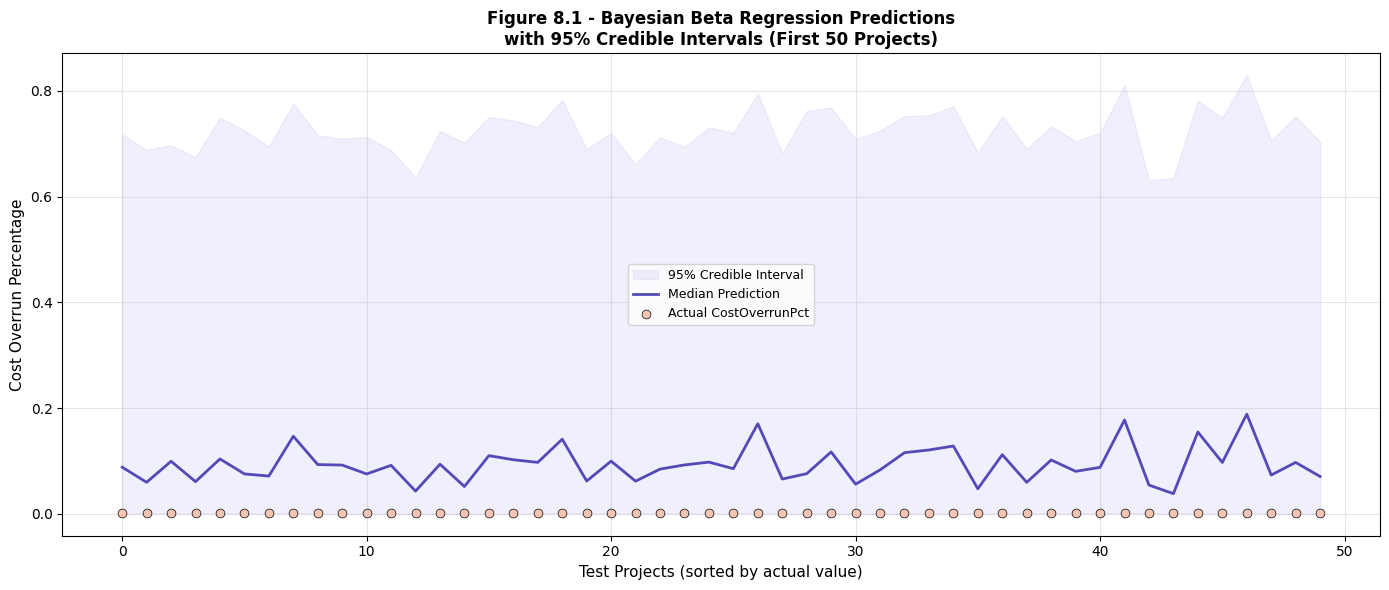

In [ ]:
#VISUALISE BAYESIAN PREDICTIONS
# Chart 1: Actual vs Predicted with credible intervals
# Sort by actual value for cleaner visualisation
sort_idx = np.argsort(y3_test_beta)
n_show   = 50  # Show first 50 sorted projects

fig, ax = plt.subplots(figsize=(14, 6))

x_plot = np.arange(n_show)

# Plot credible interval as shaded region
ax.fill_between(
    x_plot,
    lower_95[sort_idx[:n_show]],
    upper_95[sort_idx[:n_show]],
    alpha=0.3,
    color='#CECBF6',
    label='95% Credible Interval'
)

# Plot median prediction
ax.plot(
    x_plot,
    median_pred[sort_idx[:n_show]],
    color='#534AB7',
    linewidth=2,
    label='Median Prediction',
    zorder=3
)

# Plot actual values
ax.scatter(
    x_plot,
    y3_test_beta[sort_idx[:n_show]],
    color='#F5C4B3',
    s=40,
    zorder=4,
    edgecolors='black',
    linewidth=0.5,
    label='Actual CostOverrunPct'
)

ax.set_xlabel('Test Projects (sorted by actual value)',
              fontsize=11)
ax.set_ylabel('Cost Overrun Percentage', fontsize=11)
ax.set_title('Figure 8.1 - Bayesian Beta Regression Predictions\n'
             'with 95% Credible Intervals (First 50 Projects)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('fig9_1_bayesian_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()

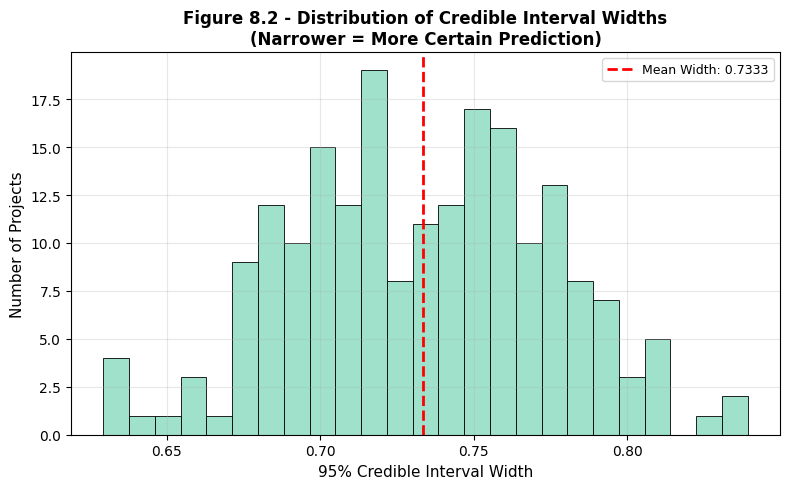

In [ ]:
# Chart 2: Credible interval width distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    interval_width,
    bins=25,
    color='#9FE1CB',
    edgecolor='black',
    linewidth=0.6
)
ax.axvline(
    avg_interval_width,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Width: {avg_interval_width:.4f}'
)
ax.set_xlabel('95% Credible Interval Width', fontsize=11)
ax.set_ylabel('Number of Projects', fontsize=11)
ax.set_title('Figure 8.2 - Distribution of Credible Interval Widths\n'
             '(Narrower = More Certain Prediction)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('fig9_2_interval_widths.png',
            dpi=150, bbox_inches='tight')
plt.show()


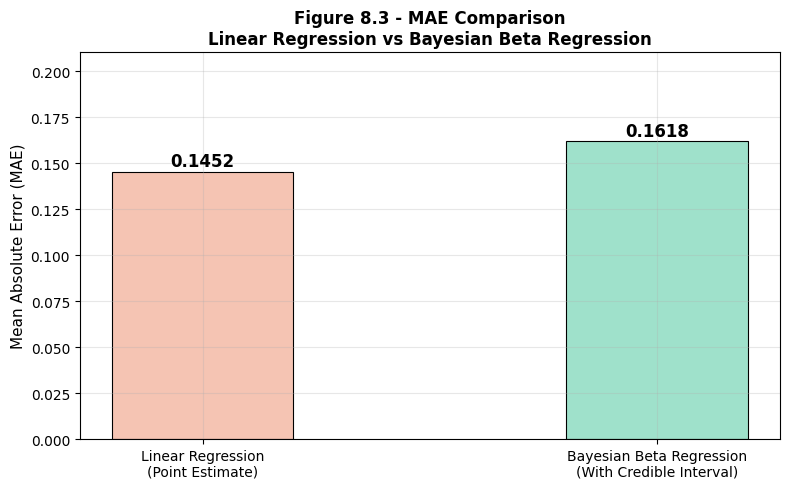

In [ ]:
# Chart 3: MAE Comparison - Bayesian vs Linear Regression
fig, ax = plt.subplots(figsize=(8, 5))

models_comp  = ['Linear Regression\n(Point Estimate)',
                'Bayesian Beta Regression\n(With Credible Interval)']
mae_values   = [mae_baseline, mae_bayesian]
colors_comp  = ['#F5C4B3', '#9FE1CB']

bars = ax.bar(
    models_comp,
    mae_values,
    color=colors_comp,
    edgecolor='black',
    linewidth=0.8,
    width=0.4
)

for bar, val in zip(bars, mae_values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=11)
ax.set_title('Figure 8.3 - MAE Comparison\n'
             'Linear Regression vs Bayesian Beta Regression',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(mae_values) * 1.3)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('fig9_3_mae_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


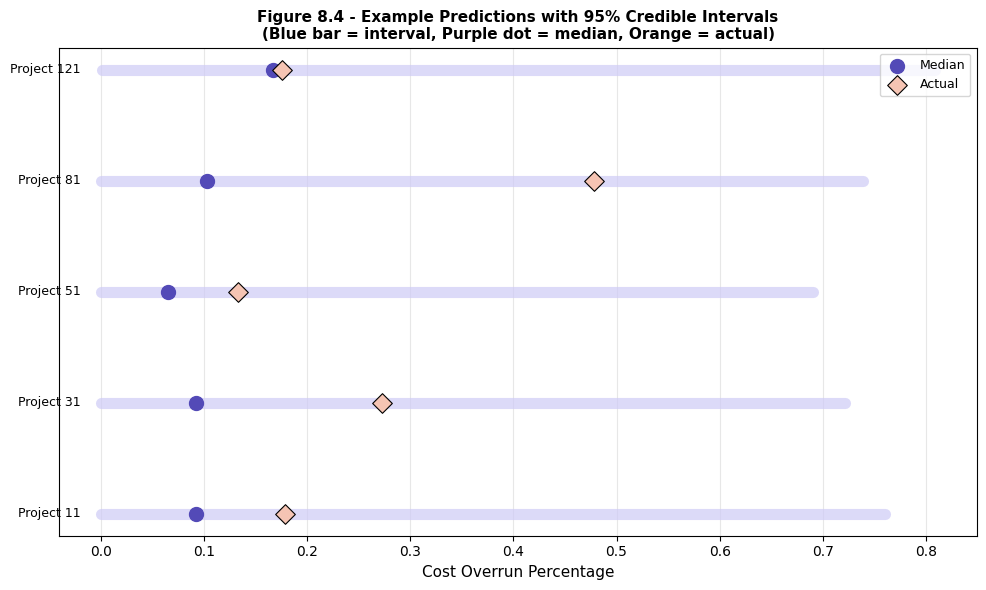

In [ ]:
# Chart 4: Example project predictions showing
# the value of the credible interval
# Pick 5 projects and show their full prediction range
fig, ax = plt.subplots(figsize=(10, 6))

# Pick 5 representative projects
example_indices = [10, 30, 50, 80, 120]

for plot_i, proj_idx in enumerate(example_indices):
    actual   = float(y3_test_beta[proj_idx])
    median_p = median_pred[proj_idx]
    lower_p  = lower_95[proj_idx]
    upper_p  = upper_95[proj_idx]

    # Plot interval
    ax.plot(
        [lower_p, upper_p],
        [plot_i, plot_i],
        color='#CECBF6',
        linewidth=8,
        alpha=0.7,
        solid_capstyle='round'
    )
    # Plot median
    ax.scatter(
        median_p, plot_i,
        color='#534AB7',
        s=100, zorder=5,
        label='Median' if plot_i == 0 else ''
    )
    # Plot actual
    ax.scatter(
        actual, plot_i,
        color='#F5C4B3',
        s=100, zorder=5,
        marker='D',
        edgecolors='black',
        linewidth=0.8,
        label='Actual' if plot_i == 0 else ''
    )
    # Label
    ax.text(
        -0.02, plot_i,
        f'Project {proj_idx+1}',
        ha='right', va='center', fontsize=9
    )

ax.set_xlabel('Cost Overrun Percentage', fontsize=11)
ax.set_title('Figure 8.4 - Example Predictions with 95% Credible Intervals\n'
             '(Blue bar = interval, Purple dot = median, Orange = actual)',
             fontsize=11, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig('fig9_4_example_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# STAGE 3 COMPLETE SUMMARY

print("=" * 60)
print("STAGE 3 - BAYESIAN BETA REGRESSION COMPLETE SUMMARY")
print("=" * 60)
print()
print(f"Model: Bayesian Beta Regression (PyMC)")
print(f"Target: CostOverrunPct")
print(f"Features used: {len(bayesian_features)}")
print(f"Training samples: {n_train}")
print(f"Test samples: {n_test}")
print()
print("Performance Metrics:")
print(f"  MAE (Bayesian):          {mae_bayesian:.4f}")
print(f"  MAE (Linear Baseline):   {mae_baseline:.4f}")
print(f"  Avg Interval Width:      {avg_interval_width:.4f}")
print(f"  Coverage (95% CI):       {coverage:.1f}%")
print()
print("Research Question 3 Answer:")
if coverage >= 85:
    print(f"  YES - Bayesian Beta Regression provides reliable")
    print(f"  credible intervals with {coverage:.1f}% empirical coverage")
    print(f"  This is significantly more informative than")
    print(f"  standard Linear Regression which provides no")
    print(f"  uncertainty estimate")
else:
    print(f"  Coverage of {coverage:.1f}% is below ideal 95%")
    print(f"  This suggests the model underestimates uncertainty")
    print(f"  This is discussed as a limitation in the research")
print()


STAGE 3 - BAYESIAN BETA REGRESSION COMPLETE SUMMARY

Model: Bayesian Beta Regression (PyMC)
Target: CostOverrunPct
Features used: 7
Training samples: 800
Test samples: 200

Performance Metrics:
  MAE (Bayesian):          0.1618
  MAE (Linear Baseline):   0.1452
  Avg Interval Width:      0.7333
  Coverage (95% CI):       98.0%

Research Question 3 Answer:
  YES - Bayesian Beta Regression provides reliable
  credible intervals with 98.0% empirical coverage
  This is significantly more informative than
  standard Linear Regression which provides no
  uncertainty estimate



In [ ]:
print(f"Bayesian MAE:        {mae_bayesian:.4f}")
print(f"Baseline LR MAE:     {mae_baseline:.4f}")
print(f"Avg interval width:  {avg_interval_width:.4f}")
print(f"Coverage:            {coverage:.1f}%")

# Also check R2 if it exists
try:
    from sklearn.metrics import r2_score
    r2 = r2_score(y3_test_beta, median_pred)
    print(f"R2 score:            {r2:.4f}")
except Exception as e:
    print(f"R2 not available: {e}")

Bayesian MAE:        0.1618
Baseline LR MAE:     0.1452
Avg interval width:  0.7333
Coverage:            98.0%
R2 score:            -0.2190


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
import numpy as np

def run_mcnemar(y_true, pred_a, pred_b):
    correct_a = (np.array(pred_a) == np.array(y_true))
    correct_b = (np.array(pred_b) == np.array(y_true))
    table = np.array([
        [sum(correct_a & correct_b), sum(correct_a & ~correct_b)],
        [sum(~correct_a & correct_b), sum(~correct_a & ~correct_b)]
    ])
    return mcnemar(table, exact=True).pvalue

stage1_preds = {
    'SVM': y_pred_svm_b,
    'Logistic Regression': y_pred_lr_b,
    'Random Forest': y_pred_rf_b,
    'CatBoost': y_pred_cb_b,
    'Stacking': y_pred_stack,
}
stage2_preds = {
    'SVM': y_pred_svm_s2,
    'Logistic Regression': y_pred_lr_s2,
    'Random Forest': y_pred_rf_s2,
    'CatBoost': y_pred_cb_s2,
    'Stacking': y_pred_stack_s2,
}

bonferroni_threshold = 0.05 / 10  # 10 pairwise comparisons per stage

for stage_name, preds, y_true in [('Stage 1', stage1_preds, y1_test), ('Stage 2', stage2_preds, y2_test)]:
    print(f"\n=== {stage_name} ===")
    for model_a, model_b in combinations(preds.keys(), 2):
        p = run_mcnemar(y_true, preds[model_a], preds[model_b])
        sig_raw = "sig (p<0.05)" if p < 0.05 else "not sig"
        sig_bonf = "sig (Bonferroni)" if p < bonferroni_threshold else "not sig (Bonferroni)"
        print(f"{model_a:22s} vs {model_b:22s}  p={p:.4f}   {sig_raw:12s}   {sig_bonf}")


=== Stage 1 ===
SVM                    vs Logistic Regression     p=0.6250   not sig        not sig (Bonferroni)
SVM                    vs Random Forest           p=0.5847   not sig        not sig (Bonferroni)
SVM                    vs CatBoost                p=0.5034   not sig        not sig (Bonferroni)
SVM                    vs Stacking                p=0.5078   not sig        not sig (Bonferroni)
Logistic Regression    vs Random Forest           p=0.8555   not sig        not sig (Bonferroni)
Logistic Regression    vs CatBoost                p=0.2863   not sig        not sig (Bonferroni)
Logistic Regression    vs Stacking                p=0.2266   not sig        not sig (Bonferroni)
Random Forest          vs CatBoost                p=0.1686   not sig        not sig (Bonferroni)
Random Forest          vs Stacking                p=0.2295   not sig        not sig (Bonferroni)
CatBoost               vs Stacking                p=1.0000   not sig        not sig (Bonferroni)

=== Stage 2 